# SME Credit Scoring & Loan Default Prediction

**Dataset:** `sme_credit_data.csv` — 25,000 SME loan records with 21 features including M-Pesa transaction data, utility bills, POS sales, and business attributes.

---
**Pipeline Overview**
```
Data Loading → EDA → Feature Engineering → Preprocessing → SMOTE →
Model Training (7 models) → Evaluation → Model Selection → 
Probability Calibration → Threshold Tuning → Credit Scoring →
Flag Rules Engine → SHAP Explainability → Deployment (FastAPI)
```

## 1. Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & model selection
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, roc_curve
)

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')

import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Data

In [2]:
df = pd.read_csv('data/sme_credit_data.csv')

print(f'Rows   : {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')

Rows   : 25,000
Columns: 21


In [3]:
# Preview the first 5 rows
df.head()

,sector,years_in_operation,num_employees,loan_amount_kes,loan_term_months,interest_rate_pct,mpesa_avg_monthly_inflow,mpesa_avg_monthly_outflow,mpesa_txn_count_monthly,mpesa_savings_ratio,electricity_payment_delays,electricity_bill_avg,water_bill_avg,social_media_active,online_ads_spend_kes,avg_monthly_data_spend,avg_monthly_airtime_spend,pos_monthly_sales,pos_txn_volume,loan_default,dataset_source
0,Manufacturing,4.5,6,783870,12,19.39,62539,20175,433,0.6774,1,795,2263,1,2406,360,1670,24647,63,0,Kenya_SME
1,Retail,1.4,3,62524,36,19.29,79149,53440,225,0.3248,6,867,1866,0,0,1426,780,306387,2118,1,Kenya_SME
2,Transport,3.3,6,375181,18,16.08,29989,20726,305,0.3089,4,2410,2601,1,550,1172,1090,133647,267,0,Kenya_SME
3,Wholesale,1.8,1,883325,12,17.37,154449,112350,509,0.2726,2,10137,1370,1,2819,3953,551,255666,812,0,Kenya_SME
4,Construction,11.9,42,1682367,24,23.76,60404,25044,104,0.5854,5,3951,8653,0,0,1623,472,28249,196,1,Kenya_SME


In [4]:
# Data types and null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   sector                      25000 non-null  object 
 1   years_in_operation          25000 non-null  float64
 2   num_employees               25000 non-null  int64  
 3   loan_amount_kes             25000 non-null  int64  
 4   loan_term_months            25000 non-null  int64  
 5   interest_rate_pct           25000 non-null  float64
 6   mpesa_avg_monthly_inflow    25000 non-null  int64  
 7   mpesa_avg_monthly_outflow   25000 non-null  int64  
 8   mpesa_txn_count_monthly     25000 non-null  int64  
 9   mpesa_savings_ratio         25000 non-null  float64
 10  electricity_payment_delays  25000 non-null  int64  
 11  electricity_bill_avg        25000 non-null  int64  
 12  water_bill_avg              25000 non-null  int64  
 13  social_media_active         250

In [5]:
# Summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
years_in_operation,25000.0,5.041284,4.948103,0.5000,1.5000,3.5000,7.000000,35.00
num_employees,25000.0,6.252960,7.575877,1.0000,2.0000,4.0000,8.000000,200.00
loan_amount_kes,25000.0,680029.462360,810339.080414,7548.0000,230843.5000,437095.5000,826383.500000,20916067.00
loan_term_months,25000.0,23.815200,13.932288,6.0000,12.0000,18.0000,36.000000,60.00
interest_rate_pct,25000.0,18.021248,4.468598,6.0000,14.9900,18.0000,21.050000,36.59
mpesa_avg_monthly_inflow,25000.0,89377.642080,104070.054252,1043.0000,32337.7500,59429.0000,107909.750000,2740346.00
mpesa_avg_monthly_outflow,25000.0,55033.832560,68084.366086,377.0000,18571.7500,35082.0000,66262.500000,2205126.00
mpesa_txn_count_monthly,25000.0,316.400040,263.332575,11.0000,150.0000,245.0000,397.000000,4871.00
mpesa_savings_ratio,25000.0,0.370992,0.192313,0.0023,0.2186,0.3535,0.510525,0.80
electricity_payment_delays,25000.0,3.022920,2.282815,0.0000,1.0000,3.0000,4.000000,20.00


In [6]:
# Check for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'None — dataset is complete.')

Missing values per column:
None — dataset is complete.


In [7]:
# Identify column types
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print(f'Numerical columns   ({len(num_cols)}): {num_cols}')
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')

Numerical columns   (19): ['years_in_operation', 'num_employees', 'loan_amount_kes', 'loan_term_months', 'interest_rate_pct', 'mpesa_avg_monthly_inflow', 'mpesa_avg_monthly_outflow', 'mpesa_txn_count_monthly', 'mpesa_savings_ratio', 'electricity_payment_delays', 'electricity_bill_avg', 'water_bill_avg', 'social_media_active', 'online_ads_spend_kes', 'avg_monthly_data_spend', 'avg_monthly_airtime_spend', 'pos_monthly_sales', 'pos_txn_volume', 'loan_default']
Categorical columns (2): ['sector', 'dataset_source']


## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable Distribution

In [8]:
counts = df['loan_default'].value_counts()
pcts   = df['loan_default'].value_counts(normalize=True) * 100

print('Loan Default Counts:')
print(pd.DataFrame({'Count': counts, 'Percentage (%)': pcts.round(2)}))

Loan Default Counts:
              Count  Percentage (%)
loan_default                       
0             18948           75.79
1              6052           24.21


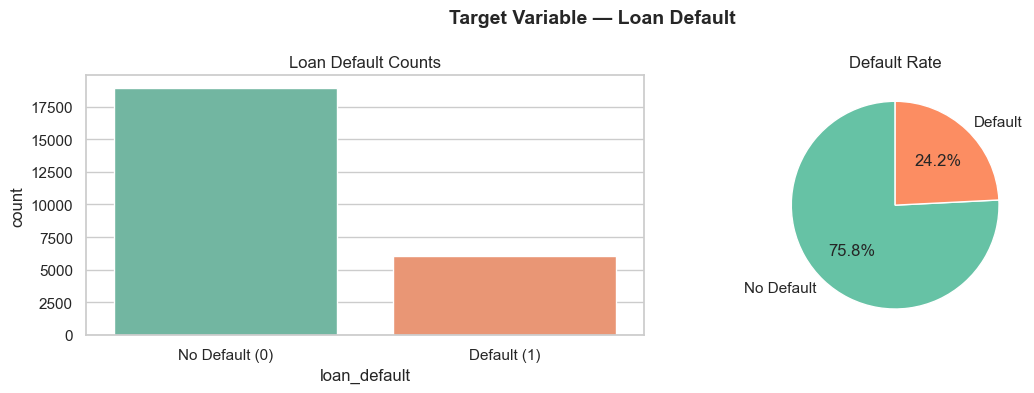

Note: The dataset is imbalanced (~24% defaults). We will use SMOTE to address this.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
sns.countplot(x='loan_default', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Loan Default Counts')
axes[0].set_xticklabels(['No Default (0)', 'Default (1)'])

# Pie chart
axes[1].pie(
    counts, labels=['No Default', 'Default'],
    autopct='%1.1f%%', startangle=90,
    colors=['#66c2a5', '#fc8d62']
)
axes[1].set_title('Default Rate')

plt.suptitle('Target Variable — Loan Default', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Note: The dataset is imbalanced (~24% defaults). We will use SMOTE to address this.')

### 3.2 Default Rate by Sector

In [10]:
sector_default = (
    df.groupby('sector')['loan_default']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
sector_default.columns = ['Sector', 'Default Rate']
sector_default['Default Rate (%)'] = (sector_default['Default Rate'] * 100).round(1)
print(sector_default.to_string(index=False))

       Sector  Default Rate  Default Rate (%)
     Informal      0.289289              28.9
 Construction      0.268174              26.8
          ICT      0.259696              26.0
 Agribusiness      0.251384              25.1
     Services      0.245766              24.6
  Hospitality      0.238448              23.8
Manufacturing      0.233801              23.4
    Wholesale      0.230709              23.1
       Retail      0.229528              23.0
    Transport      0.228309              22.8


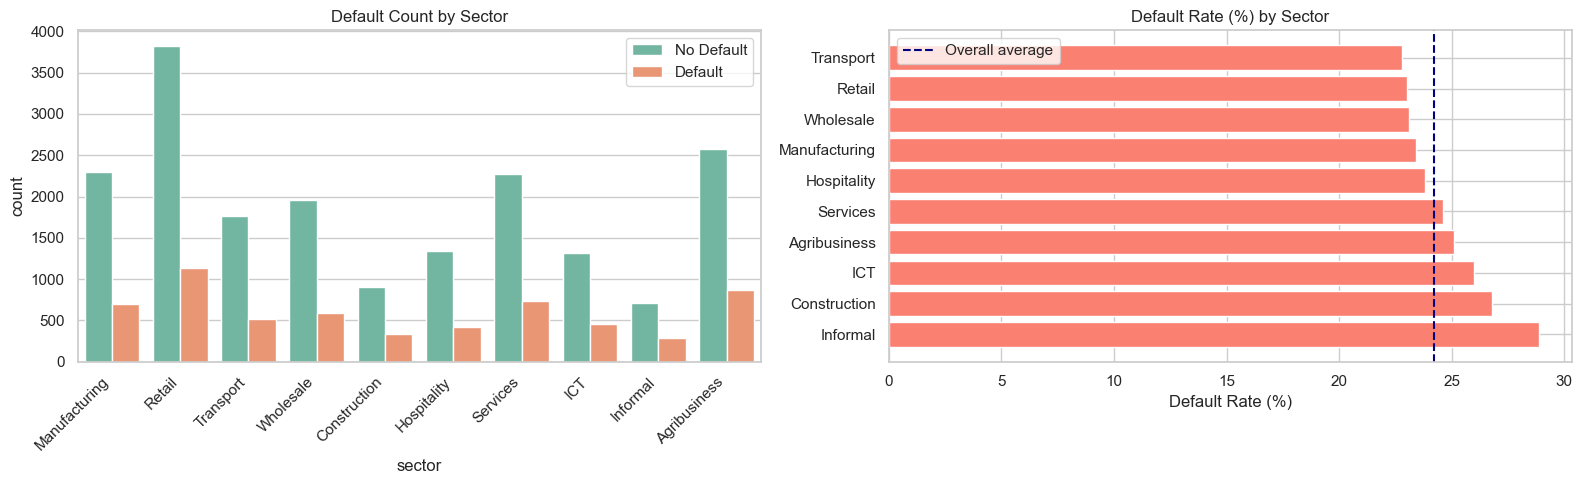

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Count plot by sector
sns.countplot(x='sector', hue='loan_default', data=df, ax=axes[0], palette='Set2')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_title('Default Count by Sector')
axes[0].legend(['No Default', 'Default'])

# Default rate bar chart
axes[1].barh(sector_default['Sector'], sector_default['Default Rate (%)'], color='salmon')
axes[1].set_xlabel('Default Rate (%)')
axes[1].set_title('Default Rate (%) by Sector')
axes[1].axvline(
    x=df['loan_default'].mean() * 100,
    color='navy', linestyle='--', label='Overall average'
)
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.3 M-Pesa Activity vs Default

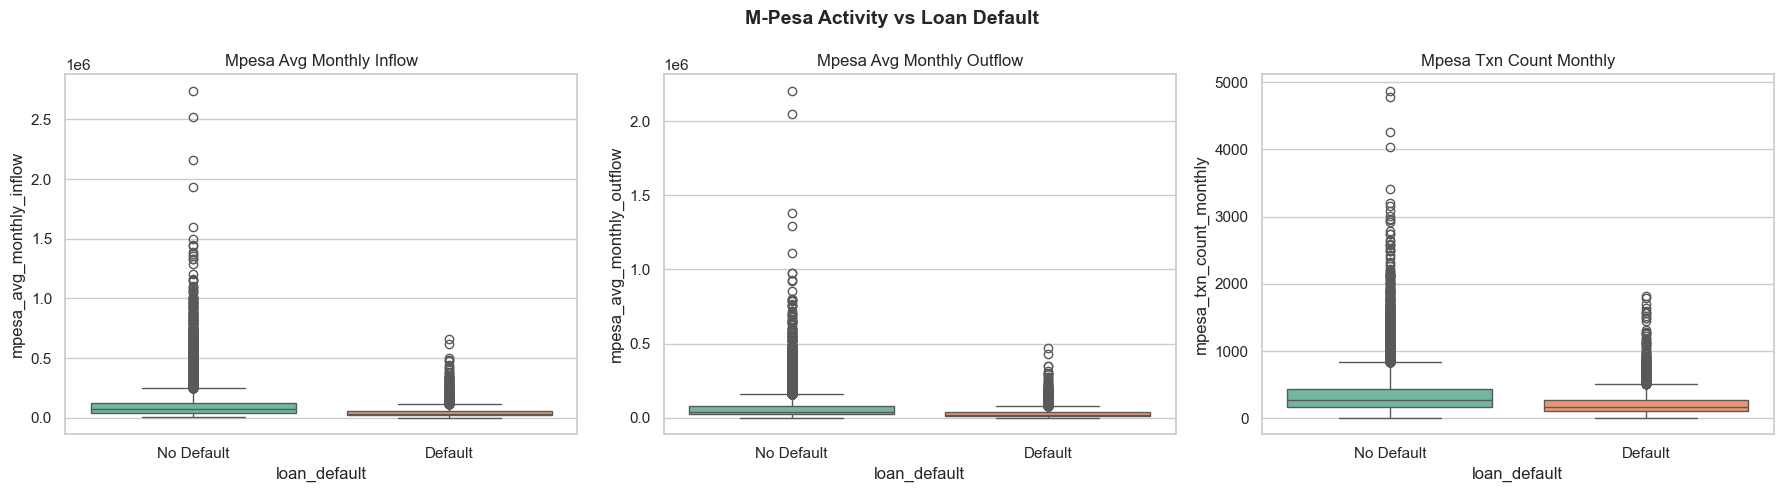

In [12]:
mpesa_cols = ['mpesa_avg_monthly_inflow', 'mpesa_avg_monthly_outflow', 'mpesa_txn_count_monthly']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, mpesa_cols):
    sns.boxplot(x='loan_default', y=col, data=df, ax=ax, palette='Set2')
    ax.set_xticklabels(['No Default', 'Default'])
    ax.set_title(col.replace('_', ' ').title())

plt.suptitle('M-Pesa Activity vs Loan Default', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Loan Characteristics vs Default

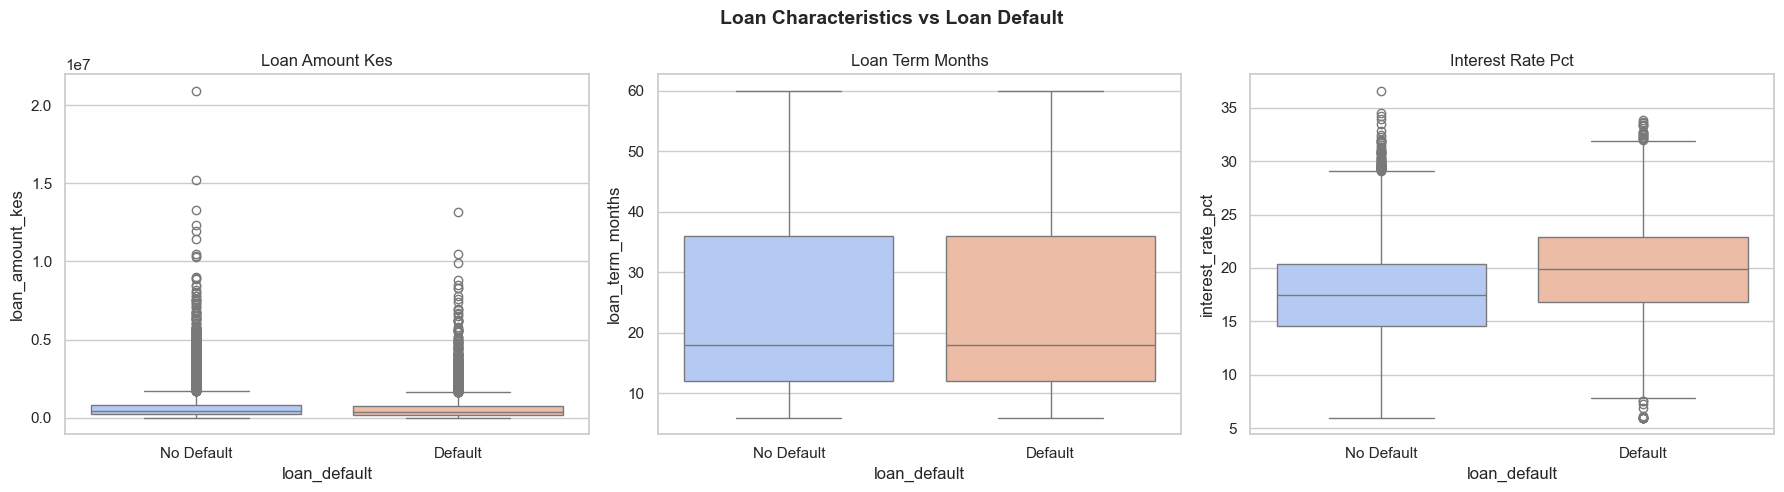

In [13]:
loan_cols = ['loan_amount_kes', 'loan_term_months', 'interest_rate_pct']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, loan_cols):
    sns.boxplot(x='loan_default', y=col, data=df, ax=ax, palette='coolwarm')
    ax.set_xticklabels(['No Default', 'Default'])
    ax.set_title(col.replace('_', ' ').title())

plt.suptitle('Loan Characteristics vs Loan Default', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5 Business Characteristics vs Default

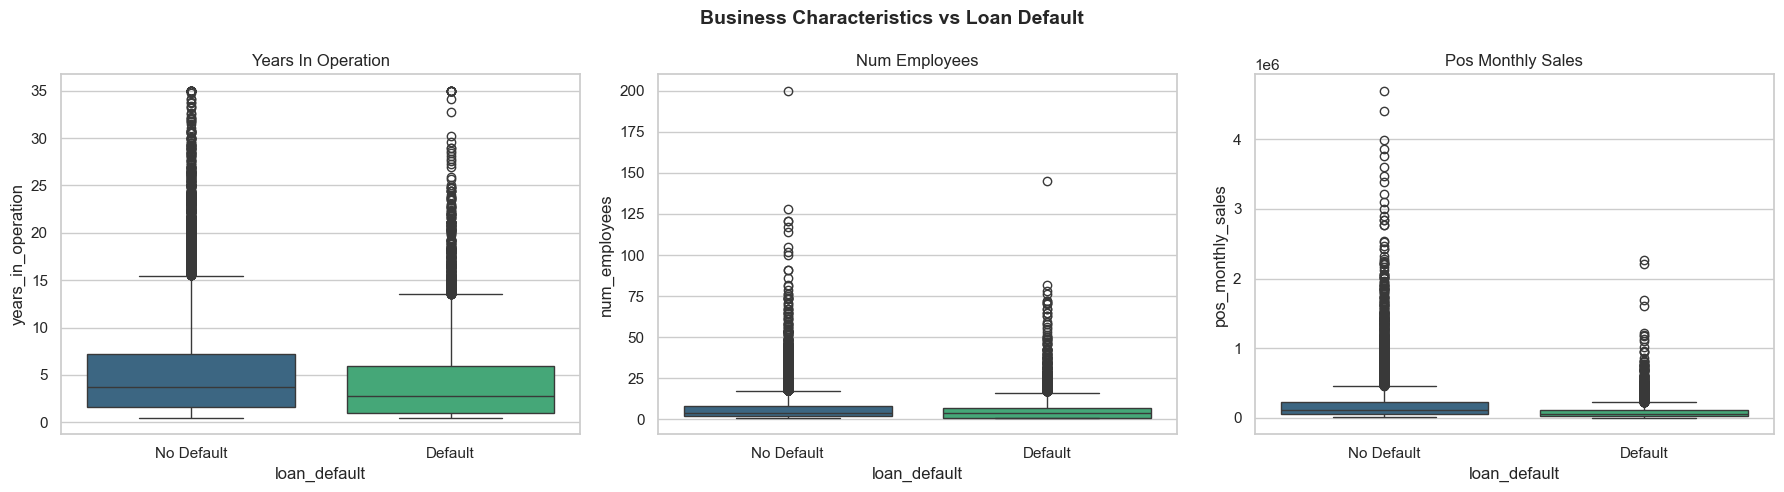

In [14]:
biz_cols = ['years_in_operation', 'num_employees', 'pos_monthly_sales']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, biz_cols):
    sns.boxplot(x='loan_default', y=col, data=df, ax=ax, palette='viridis')
    ax.set_xticklabels(['No Default', 'Default'])
    ax.set_title(col.replace('_', ' ').title())

plt.suptitle('Business Characteristics vs Loan Default', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.6 Feature Correlation Heatmap

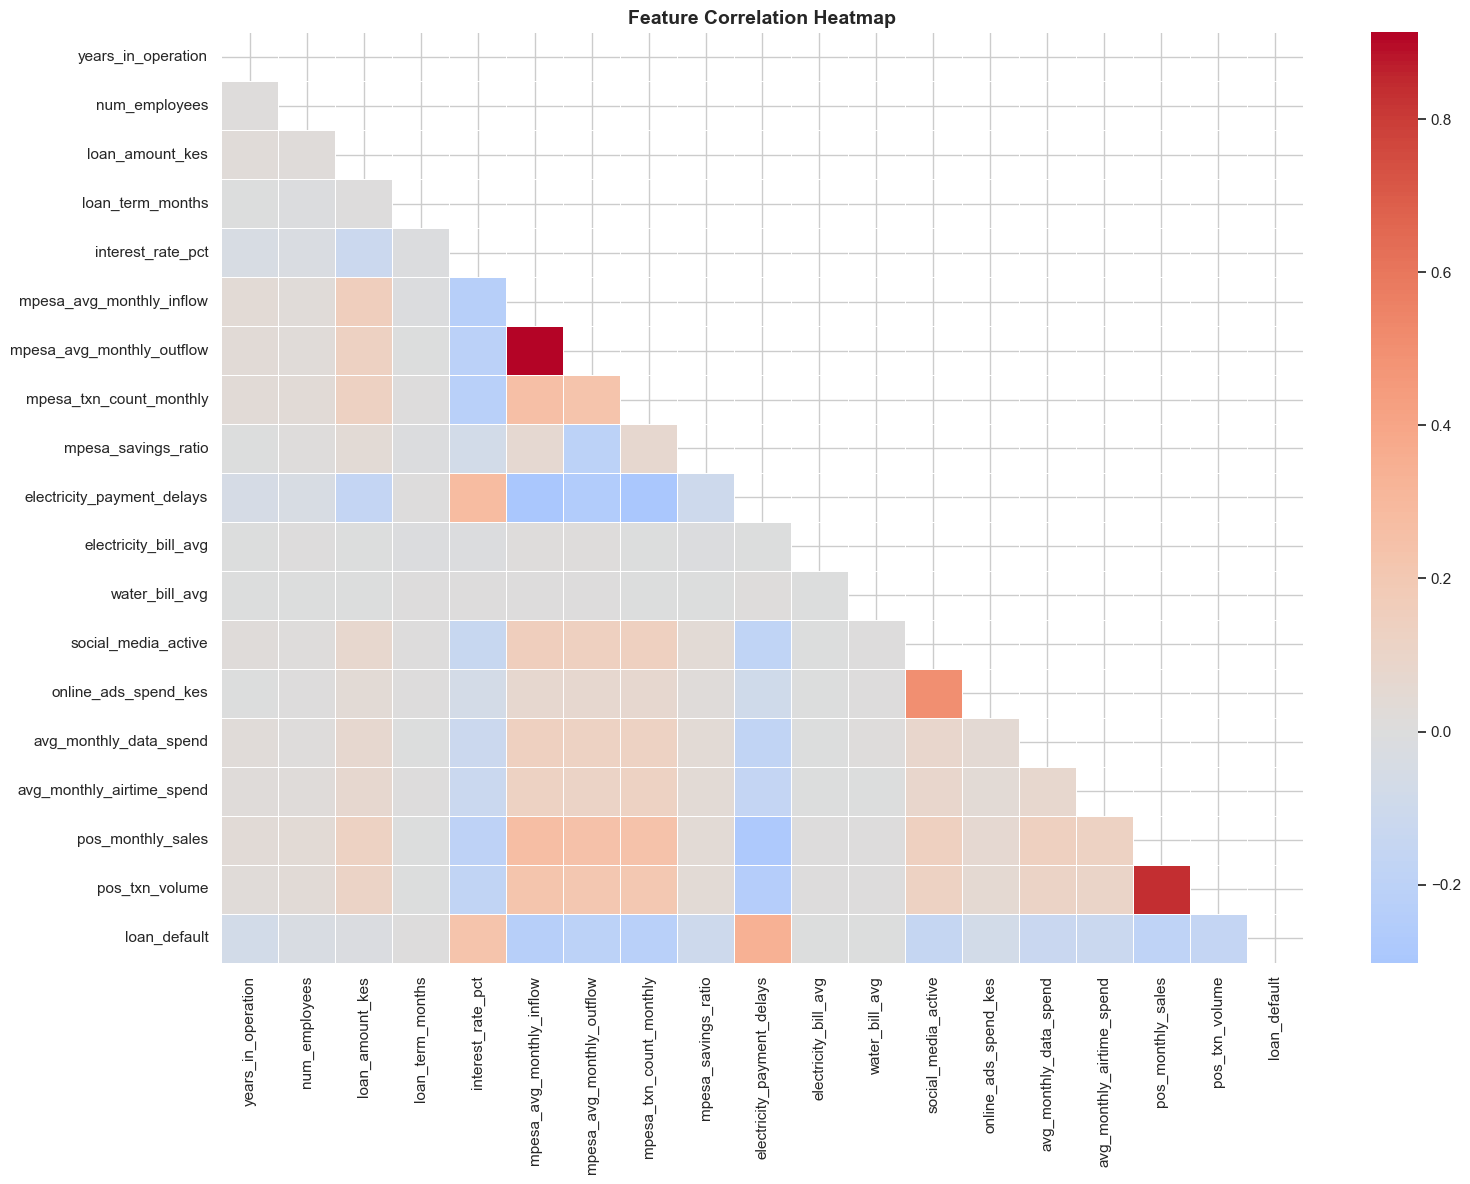

In [15]:
plt.figure(figsize=(16, 12))
corr = df.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # lower triangle only

sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, annot=False, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

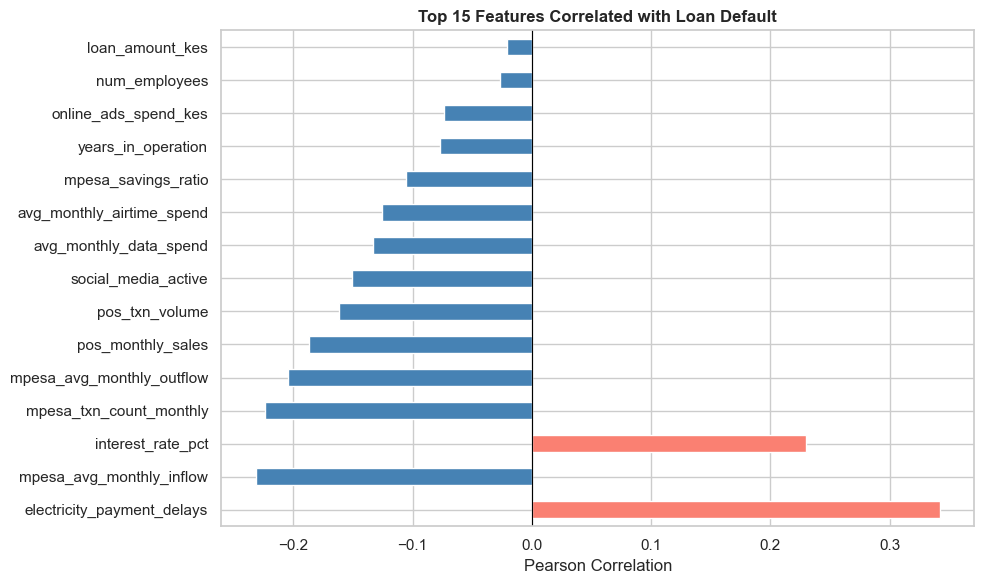

electricity_payment_delays    0.342
mpesa_avg_monthly_inflow     -0.232
interest_rate_pct             0.230
mpesa_txn_count_monthly      -0.224
mpesa_avg_monthly_outflow    -0.205
pos_monthly_sales            -0.187
pos_txn_volume               -0.161
social_media_active          -0.151
avg_monthly_data_spend       -0.133
avg_monthly_airtime_spend    -0.126
mpesa_savings_ratio          -0.106
years_in_operation           -0.077
online_ads_spend_kes         -0.074
num_employees                -0.026
loan_amount_kes              -0.021
Name: loan_default, dtype: float64


In [16]:
# Top correlations with the target
target_corr = (
    df.select_dtypes(include=np.number)
    .corr()['loan_default']
    .drop('loan_default')
    .sort_values(key=abs, ascending=False)
)

plt.figure(figsize=(10, 6))
colors = ['salmon' if x > 0 else 'steelblue' for x in target_corr.head(15)]
target_corr.head(15).plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 Features Correlated with Loan Default', fontweight='bold')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print(target_corr.head(15).round(3))

## 4. Feature Engineering

We create domain-specific composite features that better capture financial health, business activity, and risk signals.

In [17]:
df_fe = df.copy()

In [18]:
# --- Cash flow features ---

# Net cash flow (inflow minus outflow)
df_fe['cashflow_net'] = df_fe['mpesa_avg_monthly_inflow'] - df_fe['mpesa_avg_monthly_outflow']

# Ratio of inflow to outflow (higher = more financial cushion)
df_fe['cashflow_ratio'] = df_fe['mpesa_avg_monthly_inflow'] / (df_fe['mpesa_avg_monthly_outflow'] + 1)

In [19]:
# --- Loan affordability ---

# How large the loan is relative to monthly POS sales
df_fe['loan_to_sales_ratio'] = df_fe['loan_amount_kes'] / (df_fe['pos_monthly_sales'] + 1)

# Loan size relative to monthly inflow — measures credit burden
df_fe['credit_pressure'] = df_fe['loan_amount_kes'] / (df_fe['mpesa_avg_monthly_inflow'] + 1)

In [20]:
# --- Business activity & scale ---

# Combined activity: employees × monthly M-Pesa transaction count
df_fe['business_activity_score'] = df_fe['num_employees'] * df_fe['mpesa_txn_count_monthly']

# Revenue productivity per employee
df_fe['revenue_per_employee'] = df_fe['pos_monthly_sales'] / (df_fe['num_employees'] + 1)

# Business maturity proxy: years in operation × number of employees
df_fe['business_maturity'] = df_fe['years_in_operation'] * df_fe['num_employees']

In [21]:
# --- Digital presence ---

# Combined: social media active + has online ad spend (0, 1, or 2)
df_fe['digital_engagement'] = (
    df_fe['social_media_active'] +
    (df_fe['online_ads_spend_kes'] > 0).astype(int)
)

# Binary: no digital presence at all
df_fe['no_digital_activity'] = (
    (df_fe['social_media_active'] == 0) &
    (df_fe['online_ads_spend_kes'] == 0)
).astype(int)

In [22]:
# --- Utility & financial stability risk ---

# Number of electricity payment delays (direct risk signal)
df_fe['utility_risk_score'] = df_fe['electricity_payment_delays']

# Binary flag: more than 5 electricity payment delays = high utility risk
df_fe['high_utility_risk'] = (df_fe['electricity_payment_delays'] > 5).astype(int)

# Utility bills as fraction of monthly income
df_fe['expense_pressure'] = (
    (df_fe['electricity_bill_avg'] + df_fe['water_bill_avg']) /
    (df_fe['mpesa_avg_monthly_inflow'] + 1)
)

# Savings ratio combined with inflow-to-outflow ratio
df_fe['financial_stability'] = (
    df_fe['mpesa_savings_ratio'] +
    df_fe['mpesa_avg_monthly_inflow'] / (df_fe['mpesa_avg_monthly_outflow'] + 1)
)

# Income stability: inflow / (outflow + 1)
df_fe['income_stability'] = (
    df_fe['mpesa_avg_monthly_inflow'] / (df_fe['mpesa_avg_monthly_outflow'] + 1)
)

In [23]:
# Drop dataset_source — not a predictive feature
df_fe.drop(columns=['dataset_source'], inplace=True)

print(f'Shape after feature engineering: {df_fe.shape}')
print(f'New features added             : {df_fe.shape[1] - df.shape[1] + 1}')  # +1 for dropped col

Shape after feature engineering: (25000, 34)
New features added             : 14


### 4.1 Remove Highly Correlated Features

Some engineered features are near-perfect linear combinations of originals. We remove redundant pairs (|r| > 0.90) to reduce multicollinearity.

In [24]:
corr_matrix = df_fe.select_dtypes(include='number').corr().abs()

# Find all pairs with correlation above the threshold
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > 0.90:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                round(corr_matrix.iloc[i, j], 4)
            ))

print('Highly correlated feature pairs (|r| > 0.90):')
for a, b, r in high_corr_pairs:
    print(f'  {a}  <-->  {b}  |  r = {r}')

Highly correlated feature pairs (|r| > 0.90):
  mpesa_avg_monthly_outflow  <-->  mpesa_avg_monthly_inflow  |  r = 0.9132
  cashflow_ratio  <-->  mpesa_savings_ratio  |  r = 0.9032
  digital_engagement  <-->  social_media_active  |  r = 1.0
  no_digital_activity  <-->  social_media_active  |  r = 1.0
  no_digital_activity  <-->  digital_engagement  |  r = 1.0
  utility_risk_score  <-->  electricity_payment_delays  |  r = 1.0
  financial_stability  <-->  mpesa_savings_ratio  |  r = 0.936
  financial_stability  <-->  cashflow_ratio  |  r = 0.9965
  income_stability  <-->  mpesa_savings_ratio  |  r = 0.9032
  income_stability  <-->  cashflow_ratio  |  r = 1.0
  income_stability  <-->  financial_stability  |  r = 0.9965


In [25]:
# Drop the redundant features from each correlated pair
# Keeping: utility_risk_score, digital_engagement, cashflow_ratio
# Dropping: their near-identical counterparts
cols_to_drop = [
    'income_stability',            # identical to cashflow_ratio
    'financial_stability',         # ~1.0 correlated with cashflow_ratio
    'electricity_payment_delays',  # identical to utility_risk_score
    'social_media_active',         # captured in digital_engagement
    'no_digital_activity',         # inverse of digital_engagement
]

# Only drop if present (safety guard)
cols_to_drop = [c for c in cols_to_drop if c in df_fe.columns]
df_fe = df_fe.drop(columns=cols_to_drop)

print(f'Final shape after removing redundant features: {df_fe.shape}')

Final shape after removing redundant features: (25000, 29)


### 4.2 Engineered Features vs Default

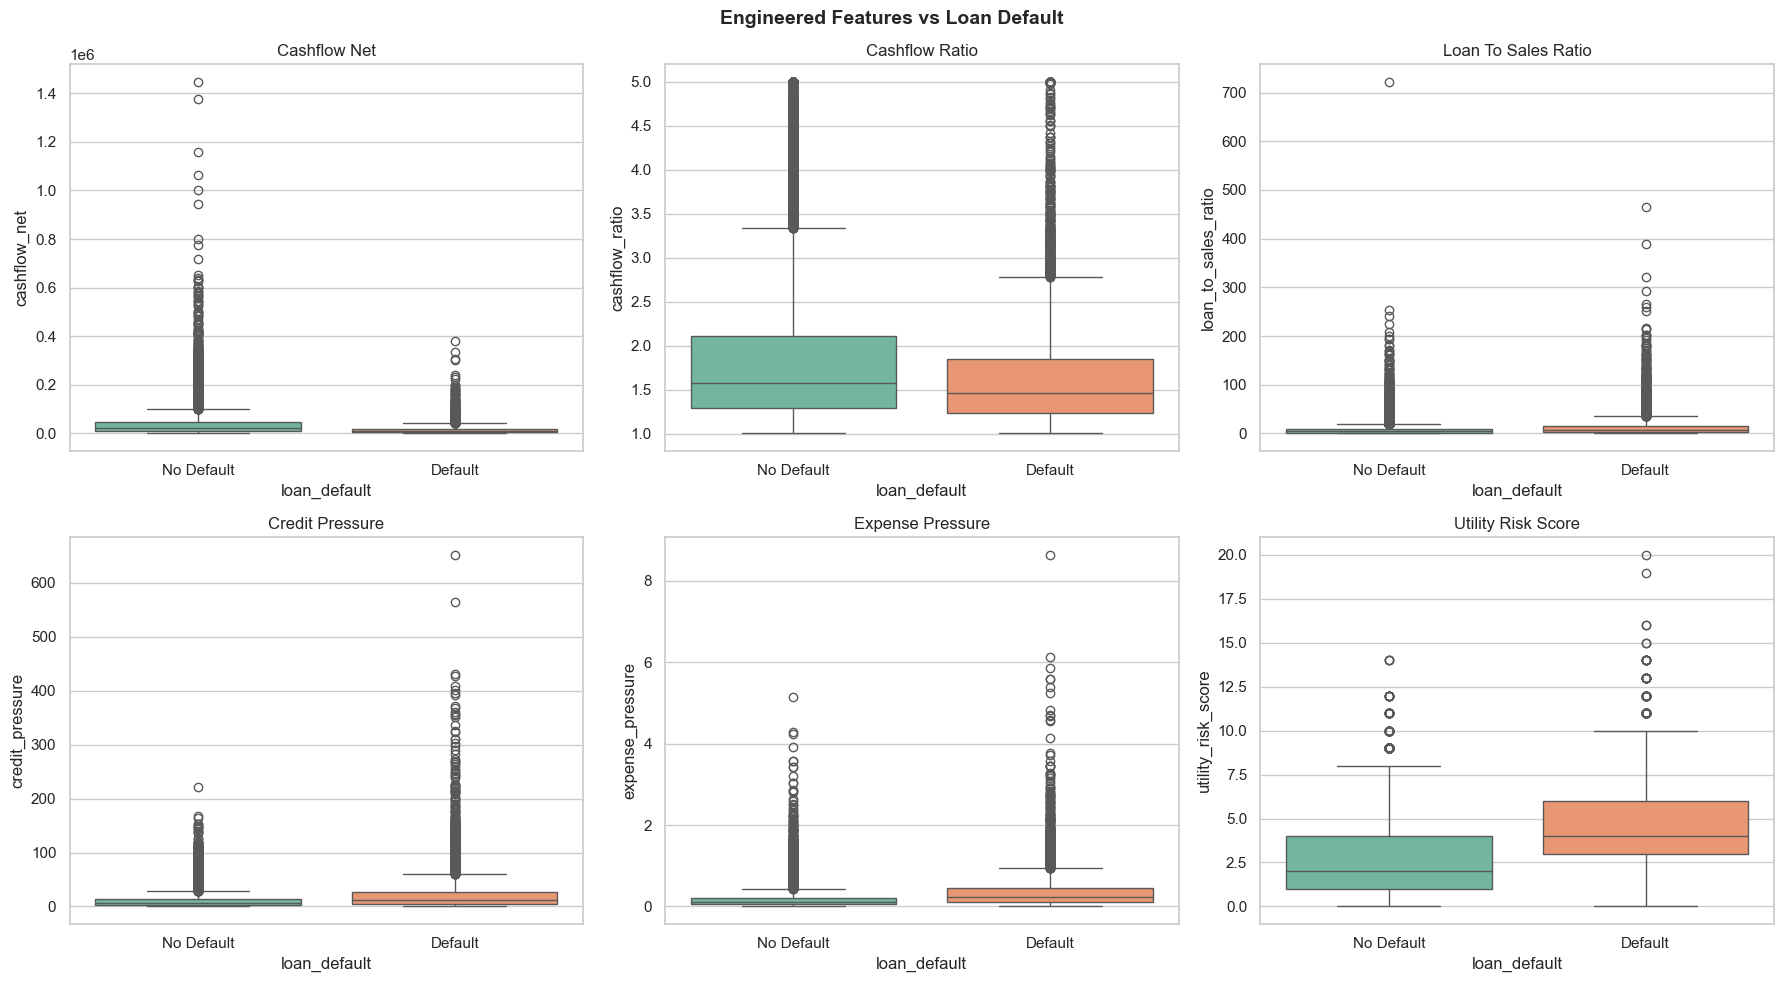

In [26]:
new_features = [
    'cashflow_net', 'cashflow_ratio', 'loan_to_sales_ratio',
    'credit_pressure', 'expense_pressure', 'utility_risk_score'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, new_features):
    sns.boxplot(x='loan_default', y=col, data=df_fe, ax=ax, palette='Set2')
    ax.set_xticklabels(['No Default', 'Default'])
    ax.set_title(col.replace('_', ' ').title())

plt.suptitle('Engineered Features vs Loan Default', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Preprocessing

### 5.1 Define Features and Target

In [27]:
X = df_fe.drop('loan_default', axis=1)
y = df_fe['loan_default']

print(f'Features (X): {X.shape}')
print(f'Target   (y): {y.shape}')
print(f'Default rate : {y.mean():.2%}')

Features (X): (25000, 28)
Target   (y): (25000,)
Default rate : 24.21%


### 5.2 Train / Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y   # preserve class proportions in both splits
)

print(f'Train set: {X_train.shape[0]:,} rows')
print(f'Test set : {X_test.shape[0]:,} rows')

Train set: 20,000 rows
Test set : 5,000 rows


### 5.3 Encode Categorical Variable (Sector)

In [29]:
# One-hot encode 'sector'; drop_first avoids the dummy variable trap
X_train = pd.get_dummies(X_train, columns=['sector'], drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=['sector'], drop_first=True)

# Align test columns to match training columns (fill any missing dummies with 0)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print(f'Train columns after encoding: {X_train.shape[1]}')
print(f'Test  columns after encoding: {X_test.shape[1]}')

Train columns after encoding: 36
Test  columns after encoding: 36


### 5.4 Scale Features

In [30]:
scaler = StandardScaler()

# Fit on train only — prevents data leakage into the test set
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Scaling complete.')

Scaling complete.


### 5.5 Handle Class Imbalance with SMOTE

The dataset is ~76% non-default / ~24% default. SMOTE generates synthetic minority-class samples **on the training set only** so models learn to identify defaulters rather than just predicting the majority class.

In [31]:
# !pip install imbalanced-learn   # uncomment if not installed
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print('Before SMOTE:')
print(y_train.value_counts().to_string())

print('\nAfter SMOTE:')
print(pd.Series(y_train_res).value_counts().to_string())

Before SMOTE:
loan_default
0    15158
1     4842

After SMOTE:
loan_default
0    15158
1    15158


## 6. Model Training & Evaluation

We train **7 classifiers** and compare them using a consistent evaluation function.
All models are trained on the SMOTE-resampled training set and evaluated on the **original held-out test set**.

**Primary metrics:** ROC-AUC and Recall for the default class — missing a real defaulter (false negative) is more costly than a false alarm (false positive).

In [32]:
def evaluate_model(name, y_true, y_pred, y_prob):
    """
    Print classification metrics and return them as a dict.

    Parameters
    ----------
    name   : str   — model name
    y_true : array — true labels
    y_pred : array — predicted labels
    y_prob : array — predicted probabilities for class 1

    Returns
    -------
    dict of metric scores
    """
    results = {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall'   : round(recall_score(y_true, y_pred), 4),
        'F1'       : round(f1_score(y_true, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_true, y_prob), 4),
    }
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    for k, v in results.items():
        if k != 'Model':
            print(f"  {k:<12}: {v}")
    print()
    print(classification_report(y_true, y_pred, target_names=['No Default', 'Default']))
    return results


# Storage for all model results
all_results   = []
all_models    = {}   # name -> model object
all_probs     = {}   # name -> predicted probabilities
all_preds     = {}   # name -> predicted labels

### 6.1 Logistic Regression (Baseline)

In [33]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000, solver='lbfgs', random_state=42)
lr.fit(X_train_res, y_train_res)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [34]:
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

all_results.append(evaluate_model('Logistic Regression', y_test, y_pred_lr, y_prob_lr))
all_models['Logistic Regression'] = lr
all_probs ['Logistic Regression'] = y_prob_lr
all_preds ['Logistic Regression'] = y_pred_lr


  Logistic Regression
  Accuracy    : 0.7366
  Precision   : 0.4717
  Recall      : 0.738
  F1          : 0.5756
  ROC-AUC     : 0.8208

              precision    recall  f1-score   support

  No Default       0.90      0.74      0.81      3790
     Default       0.47      0.74      0.58      1210

    accuracy                           0.74      5000
   macro avg       0.68      0.74      0.69      5000
weighted avg       0.79      0.74      0.75      5000



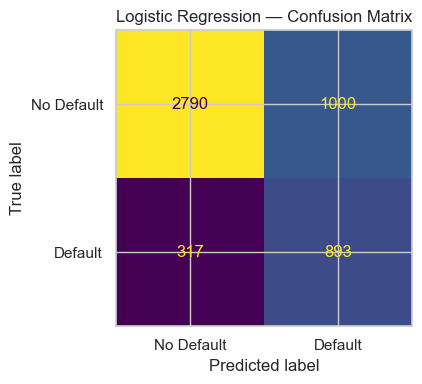

In [35]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['No Default', 'Default'],
    ax=ax, colorbar=False
)
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

### 6.2 Random Forest

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

all_results.append(evaluate_model('Random Forest', y_test, y_pred_rf, y_prob_rf))
all_models['Random Forest'] = rf
all_probs ['Random Forest'] = y_prob_rf
all_preds ['Random Forest'] = y_pred_rf


  Random Forest
  Accuracy    : 0.7826
  Precision   : 0.5488
  Recall      : 0.5711
  F1          : 0.5597
  ROC-AUC     : 0.809

              precision    recall  f1-score   support

  No Default       0.86      0.85      0.86      3790
     Default       0.55      0.57      0.56      1210

    accuracy                           0.78      5000
   macro avg       0.71      0.71      0.71      5000
weighted avg       0.79      0.78      0.78      5000



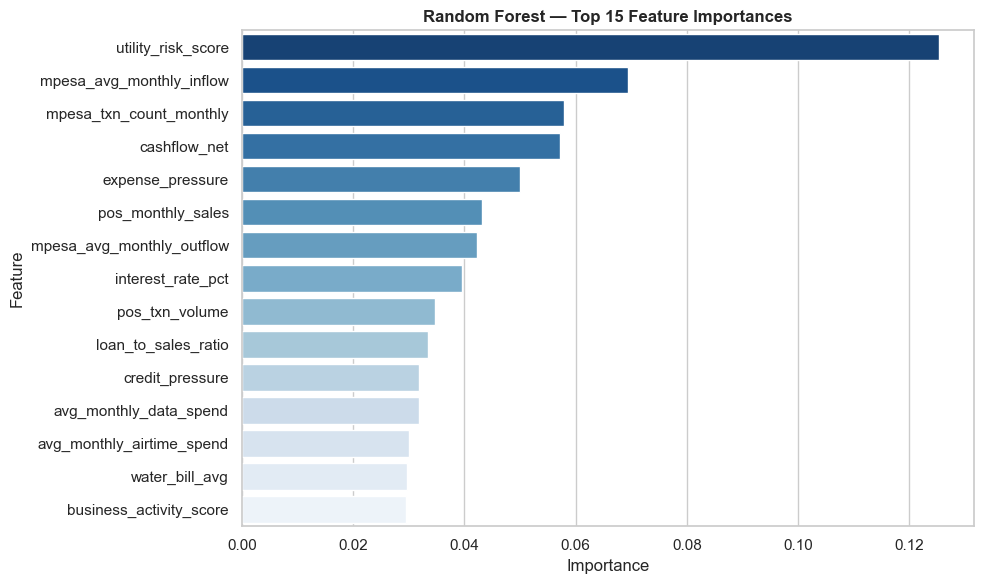

In [38]:
# Feature importances — Random Forest
rf_importance = (
    pd.DataFrame({'Feature': X_train.columns, 'Importance': rf.feature_importances_})
    .sort_values('Importance', ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_importance, palette='Blues_r')
plt.title('Random Forest — Top 15 Feature Importances', fontweight='bold')
plt.tight_layout()
plt.show()

### 6.3 Gradient Boosting

In [39]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42
)
gb.fit(X_train_res, y_train_res)

,loss,'log_loss'
,learning_rate,0.05
,n_estimators,300
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


In [40]:
y_pred_gb = gb.predict(X_test_scaled)
y_prob_gb = gb.predict_proba(X_test_scaled)[:, 1]

all_results.append(evaluate_model('Gradient Boosting', y_test, y_pred_gb, y_prob_gb))
all_models['Gradient Boosting'] = gb
all_probs ['Gradient Boosting'] = y_prob_gb
all_preds ['Gradient Boosting'] = y_pred_gb


  Gradient Boosting
  Accuracy    : 0.8028
  Precision   : 0.6148
  Recall      : 0.4959
  F1          : 0.5489
  ROC-AUC     : 0.8165

              precision    recall  f1-score   support

  No Default       0.85      0.90      0.87      3790
     Default       0.61      0.50      0.55      1210

    accuracy                           0.80      5000
   macro avg       0.73      0.70      0.71      5000
weighted avg       0.79      0.80      0.80      5000



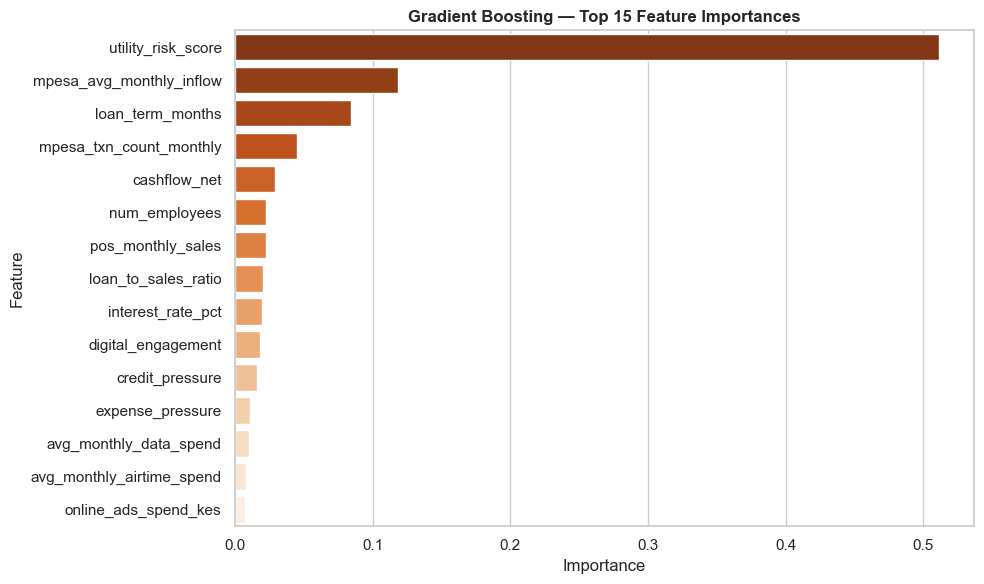

In [41]:
# Feature importances — Gradient Boosting
gb_importance = (
    pd.DataFrame({'Feature': X_train.columns, 'Importance': gb.feature_importances_})
    .sort_values('Importance', ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=gb_importance, palette='Oranges_r')
plt.title('Gradient Boosting — Top 15 Feature Importances', fontweight='bold')
plt.tight_layout()
plt.show()

### 6.4 XGBoost

In [42]:
# !pip install xgboost   # uncomment if not installed
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)
xgb.fit(X_train_res, y_train_res)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [43]:
y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

all_results.append(evaluate_model('XGBoost', y_test, y_pred_xgb, y_prob_xgb))
all_models['XGBoost'] = xgb
all_probs ['XGBoost'] = y_prob_xgb
all_preds ['XGBoost'] = y_pred_xgb


  XGBoost
  Accuracy    : 0.8058
  Precision   : 0.6238
  Recall      : 0.4975
  F1          : 0.5536
  ROC-AUC     : 0.8182

              precision    recall  f1-score   support

  No Default       0.85      0.90      0.88      3790
     Default       0.62      0.50      0.55      1210

    accuracy                           0.81      5000
   macro avg       0.74      0.70      0.71      5000
weighted avg       0.79      0.81      0.80      5000



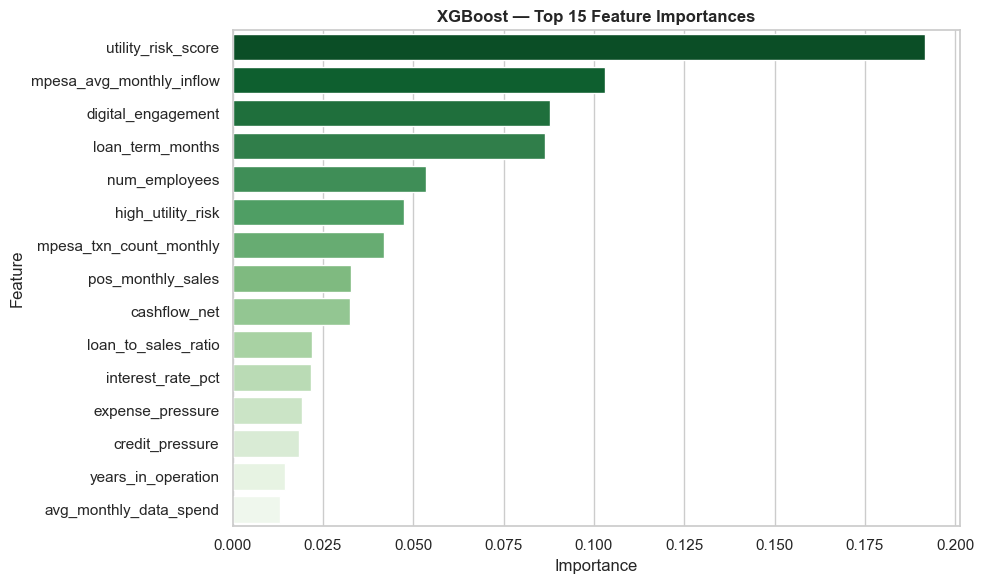

In [44]:
# Feature importances — XGBoost
xgb_importance = (
    pd.DataFrame({'Feature': X_train.columns, 'Importance': xgb.feature_importances_})
    .sort_values('Importance', ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=xgb_importance, palette='Greens_r')
plt.title('XGBoost — Top 15 Feature Importances', fontweight='bold')
plt.tight_layout()
plt.show()

### 6.5 LightGBM

In [45]:
# !pip install lightgbm   # uncomment if not installed
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1   # suppress training output
)
lgb.fit(X_train_res, y_train_res)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,400
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [46]:
# Pass feature names explicitly to avoid LightGBM feature-name warnings
X_test_lgb = pd.DataFrame(X_test_scaled, columns=X_train.columns)

y_pred_lgb = lgb.predict(X_test_lgb)
y_prob_lgb = lgb.predict_proba(X_test_lgb)[:, 1]

all_results.append(evaluate_model('LightGBM', y_test, y_pred_lgb, y_prob_lgb))
all_models['LightGBM'] = lgb
all_probs ['LightGBM'] = y_prob_lgb
all_preds ['LightGBM'] = y_pred_lgb


  LightGBM
  Accuracy    : 0.8042
  Precision   : 0.6279
  Recall      : 0.4686
  F1          : 0.5367
  ROC-AUC     : 0.8168

              precision    recall  f1-score   support

  No Default       0.84      0.91      0.88      3790
     Default       0.63      0.47      0.54      1210

    accuracy                           0.80      5000
   macro avg       0.74      0.69      0.71      5000
weighted avg       0.79      0.80      0.79      5000



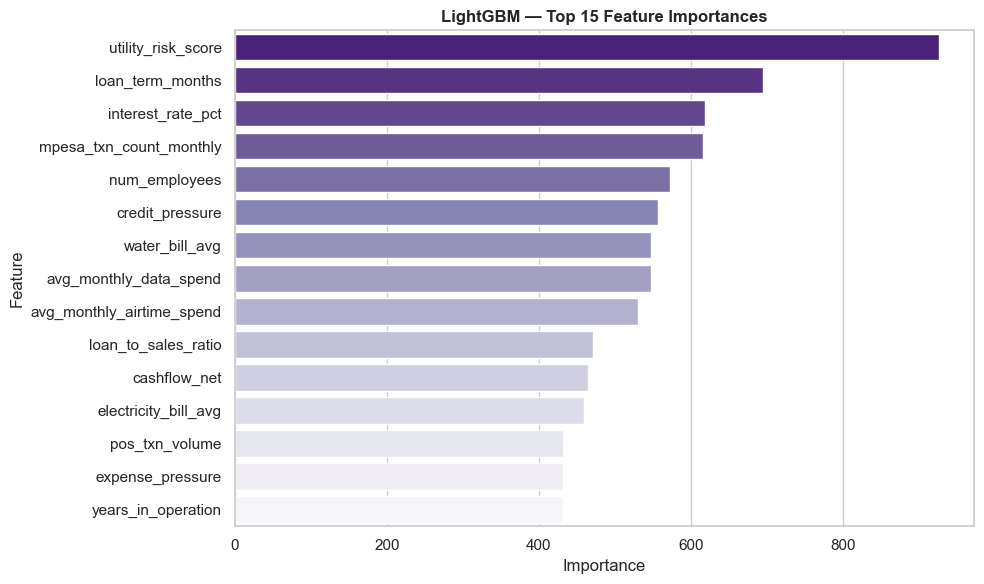

In [47]:
# Feature importances — LightGBM
lgb_importance = (
    pd.DataFrame({'Feature': X_train.columns, 'Importance': lgb.feature_importances_})
    .sort_values('Importance', ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=lgb_importance, palette='Purples_r')
plt.title('LightGBM — Top 15 Feature Importances', fontweight='bold')
plt.tight_layout()
plt.show()

### 6.6 CatBoost

In [48]:
# !pip install catboost   # uncomment if not installed
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=400,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    random_seed=42,
    verbose=0   # suppress training output
)
cat.fit(X_train_res, y_train_res)

CatBoostClassifier(depth=6, iterations=400, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=0)

In [49]:
y_pred_cat = cat.predict(X_test_scaled)
y_prob_cat = cat.predict_proba(X_test_scaled)[:, 1]

all_results.append(evaluate_model('CatBoost', y_test, y_pred_cat, y_prob_cat))
all_models['CatBoost'] = cat
all_probs ['CatBoost'] = y_prob_cat
all_preds ['CatBoost'] = y_pred_cat


  CatBoost
  Accuracy    : 0.8086
  Precision   : 0.6398
  Recall      : 0.4785
  F1          : 0.5475
  ROC-AUC     : 0.8217

              precision    recall  f1-score   support

  No Default       0.85      0.91      0.88      3790
     Default       0.64      0.48      0.55      1210

    accuracy                           0.81      5000
   macro avg       0.74      0.70      0.71      5000
weighted avg       0.80      0.81      0.80      5000



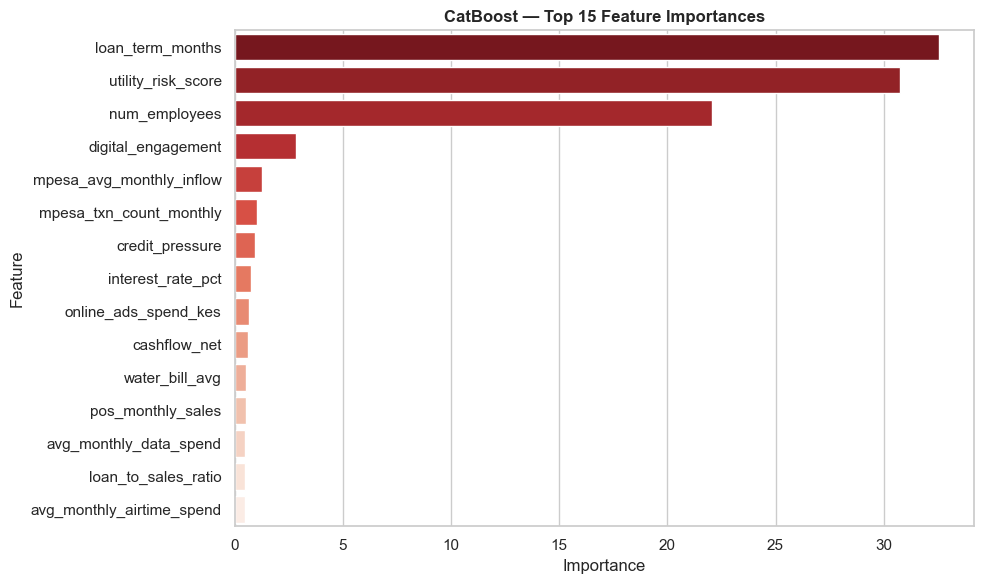

In [50]:
# Feature importances — CatBoost
cat_importance = (
    pd.DataFrame({'Feature': X_train.columns, 'Importance': cat.get_feature_importance()})
    .sort_values('Importance', ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=cat_importance, palette='Reds_r')
plt.title('CatBoost — Top 15 Feature Importances', fontweight='bold')
plt.tight_layout()
plt.show()

### 6.7 MLP Neural Network

In [51]:
from sklearn.neural_network import MLPClassifier

# Two hidden layers (64 → 32 neurons), relu activation, Adam optimiser
# max_iter increased to 200 to allow convergence
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=200,
    early_stopping=True,     # stop when validation loss stops improving
    validation_fraction=0.1,
    random_state=42
)
mlp.fit(X_train_res, y_train_res)

print(f'Training stopped after {mlp.n_iter_} iterations.')

Training stopped after 89 iterations.


In [52]:
y_pred_mlp = mlp.predict(X_test_scaled)
y_prob_mlp = mlp.predict_proba(X_test_scaled)[:, 1]

all_results.append(evaluate_model('MLP Neural Network', y_test, y_pred_mlp, y_prob_mlp))
all_models['MLP Neural Network'] = mlp
all_probs ['MLP Neural Network'] = y_prob_mlp
all_preds ['MLP Neural Network'] = y_pred_mlp


  MLP Neural Network
  Accuracy    : 0.7032
  Precision   : 0.4196
  Recall      : 0.5909
  F1          : 0.4907
  ROC-AUC     : 0.7431

              precision    recall  f1-score   support

  No Default       0.85      0.74      0.79      3790
     Default       0.42      0.59      0.49      1210

    accuracy                           0.70      5000
   macro avg       0.63      0.66      0.64      5000
weighted avg       0.75      0.70      0.72      5000



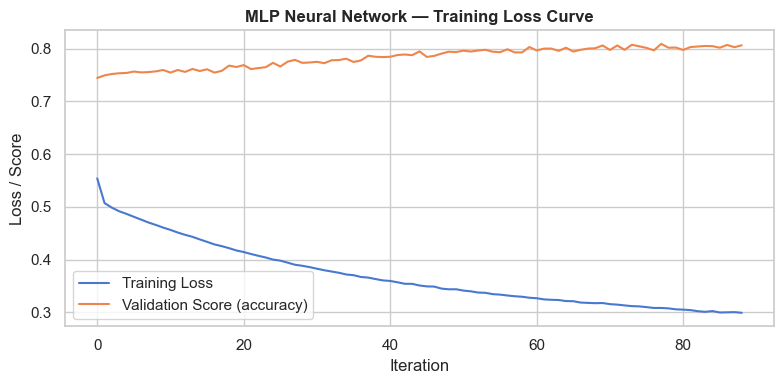

In [53]:
# MLP loss curve
plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_curve_, label='Training Loss')
if mlp.validation_scores_ is not None:
    plt.plot(mlp.validation_scores_, label='Validation Score (accuracy)')
plt.xlabel('Iteration')
plt.ylabel('Loss / Score')
plt.title('MLP Neural Network — Training Loss Curve', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Model Comparison & Selection

In [54]:
# Compile all results into a comparison table sorted by ROC-AUC
results_df = pd.DataFrame(all_results).set_index('Model')
results_df = results_df.sort_values('ROC-AUC', ascending=False)

# Highlight best value in each metric column
results_df.style.highlight_max(axis=0, props='background-color: lightgreen; font-weight: bold')

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
CatBoost,0.808600,0.639800,0.478500,0.547500,0.821700
Logistic Regression,0.736600,0.471700,0.738000,0.575600,0.820800
XGBoost,0.805800,0.623800,0.497500,0.553600,0.818200
LightGBM,0.804200,0.627900,0.468600,0.536700,0.816800
Gradient Boosting,0.802800,0.614800,0.495900,0.548900,0.816500
Random Forest,0.782600,0.548800,0.571100,0.559700,0.809000
MLP Neural Network,0.703200,0.419600,0.590900,0.490700,0.743100


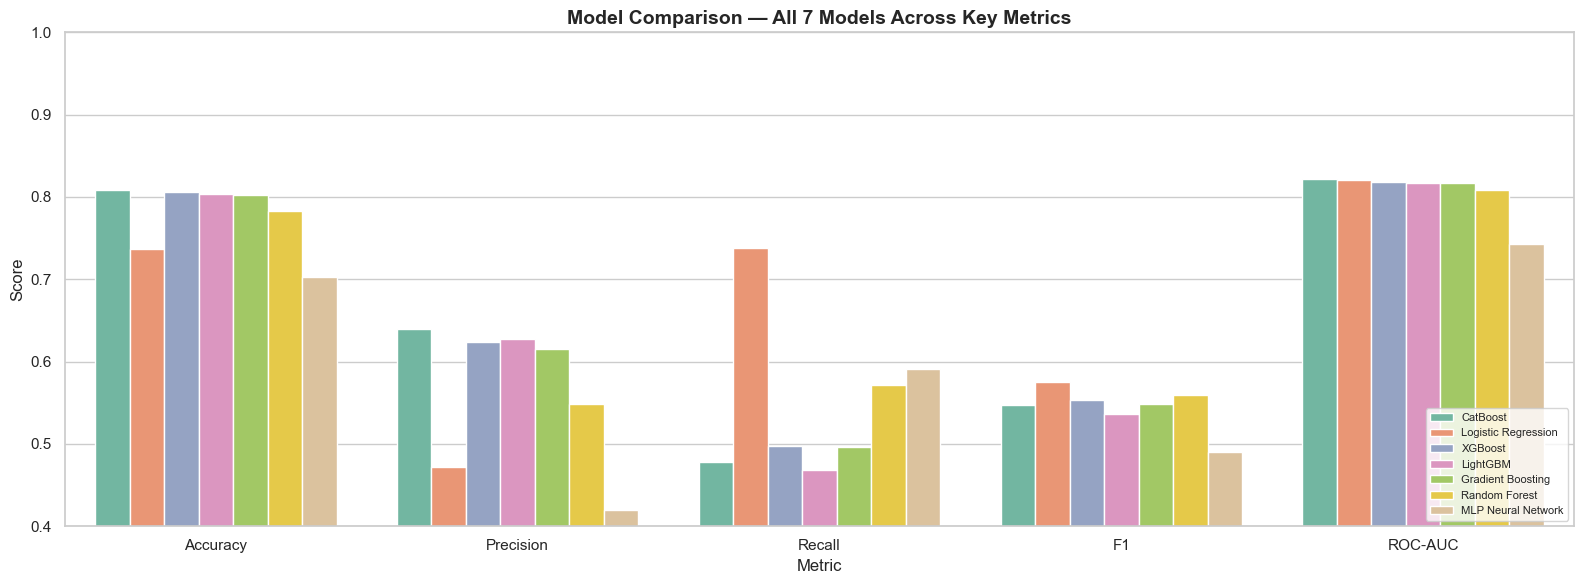

In [55]:
# Visual comparison across all metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
results_plot = (
    results_df[metrics]
    .reset_index()
    .melt(id_vars='Model', var_name='Metric', value_name='Score')
)

plt.figure(figsize=(16, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=results_plot, palette='Set2')
plt.ylim(0.4, 1.0)
plt.title('Model Comparison — All 7 Models Across Key Metrics', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

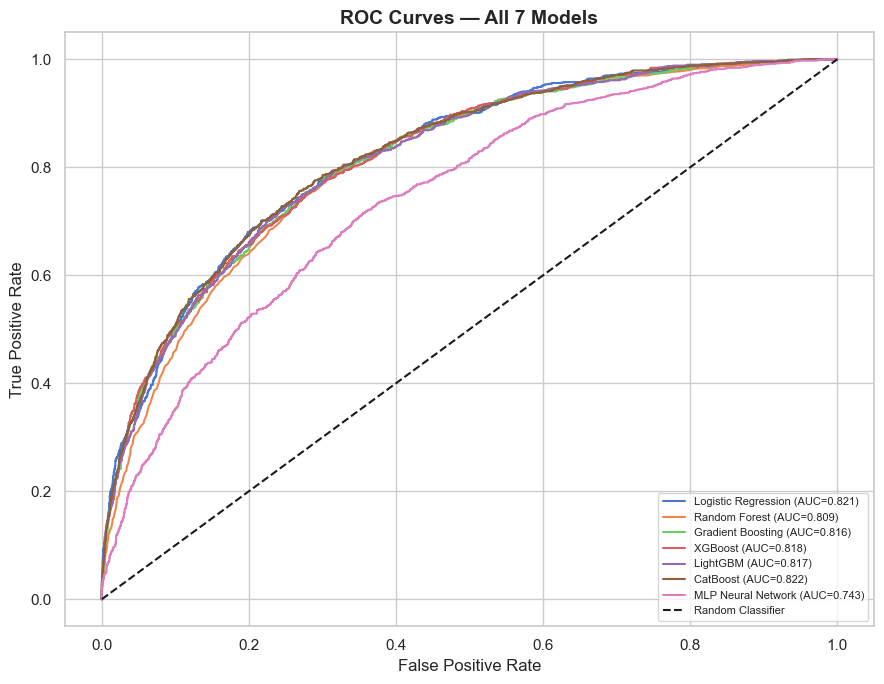

In [56]:
# ROC curves for all 7 models
plt.figure(figsize=(9, 7))

for name, probs in all_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All 7 Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

In [57]:
# Automatically select the best model by ROC-AUC
best_model_name = results_df['ROC-AUC'].idxmax()

print(f'Best model: {best_model_name}')
print()
print(results_df.loc[best_model_name])

best_model = all_models[best_model_name]
best_probs = all_probs [best_model_name]
best_preds = all_preds [best_model_name]

Best model: CatBoost

Accuracy     0.8086
Precision    0.6398
Recall       0.4785
F1           0.5475
ROC-AUC      0.8217
Name: CatBoost, dtype: float64


## 8. Cross-Validation of Best Model

In [58]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validate on the original (non-resampled) training set to get a fair estimate
cv_auc = cross_val_score(best_model, X_train_scaled, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
cv_f1  = cross_val_score(best_model, X_train_scaled, y_train, cv=cv, scoring='f1',      n_jobs=-1)

print(f'5-Fold Cross-Validation — {best_model_name}')
print(f'  AUC: Mean={cv_auc.mean():.4f}  Std={cv_auc.std():.4f}  |  Fold scores: {cv_auc.round(4)}')
print(f'  F1 : Mean={cv_f1.mean():.4f}  Std={cv_f1.std():.4f}  |  Fold scores: {cv_f1.round(4)}')

5-Fold Cross-Validation — CatBoost
  AUC: Mean=0.8116  Std=0.0065  |  Fold scores: [0.8023 0.817  0.8093 0.8207 0.8086]
  F1 : Mean=0.4812  Std=0.0117  |  Fold scores: [0.4929 0.4732 0.4627 0.4929 0.4843]


## 9. Probability Calibration

Tree-based models can produce overconfident probabilities (probabilities bunched near 0 or 1). We apply **Platt scaling** (logistic regression on the raw model's outputs) so that a predicted probability of 0.7 genuinely means ~70% default chance.

This makes the resulting credit scores more reliable.

**Approach:**
1. Split the resampled training set into a base-training set and a calibration set
2. Train the best model on the base-training set
3. Predict probabilities on the calibration set
4. Fit a Logistic Regression calibrator on those raw probabilities
5. Use the calibrator to produce final probabilities on the test set

In [59]:
from sklearn.linear_model import LogisticRegression as LRCalibrator
from sklearn.calibration import calibration_curve

# Step 1: Split resampled training data into base-train and calibration sets
X_train_base, X_calib, y_train_base, y_calib = train_test_split(
    X_train_res, y_train_res,
    test_size=0.20,
    random_state=42,
    stratify=y_train_res
)

print(f'Base training set : {X_train_base.shape[0]:,} rows')
print(f'Calibration set   : {X_calib.shape[0]:,} rows')

Base training set : 24,252 rows
Calibration set   : 6,064 rows


In [60]:
# Step 2: Re-train the best model on the base-training set
# We clone it to avoid overwriting the original best_model
from sklearn.base import clone

best_model_calib = clone(best_model)
best_model_calib.fit(X_train_base, y_train_base)

print(f'{best_model_name} re-trained on base set.')

CatBoost re-trained on base set.


In [61]:
# Step 3: Get raw probabilities on the calibration set
calib_raw_probs = best_model_calib.predict_proba(X_calib)[:, 1]

In [62]:
# Step 4: Fit the Platt scaling calibrator
calibrator = LRCalibrator()
calibrator.fit(calib_raw_probs.reshape(-1, 1), y_calib)

print('Calibrator fitted (Platt scaling).')

Calibrator fitted (Platt scaling).


In [63]:
# Step 5: Generate calibrated probabilities on the test set
test_raw_probs   = best_model_calib.predict_proba(X_test_scaled)[:, 1]
calibrated_probs = calibrator.predict_proba(test_raw_probs.reshape(-1, 1))[:, 1]

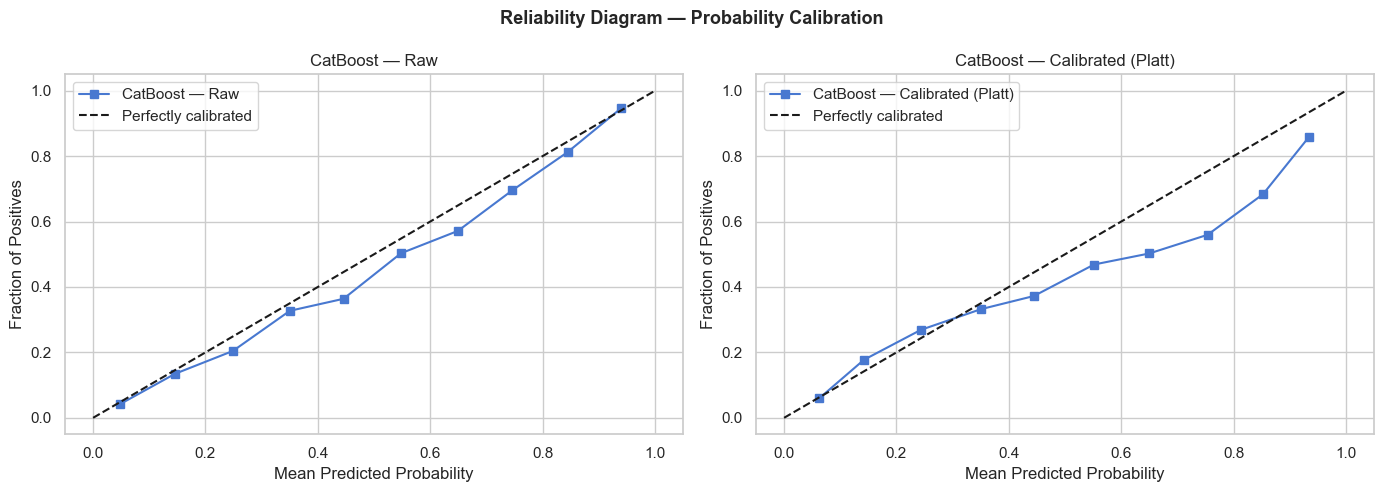

In [64]:
# Reliability diagram: compare raw vs calibrated probabilities
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (probs, label) in zip(axes, [
    (test_raw_probs,   f'{best_model_name} — Raw'),
    (calibrated_probs, f'{best_model_name} — Calibrated (Platt)')
]):
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10)
    ax.plot(mean_pred, frac_pos, 's-', label=label)
    ax.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title(label)
    ax.legend()

plt.suptitle('Reliability Diagram — Probability Calibration', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [65]:
# Evaluate the model using calibrated probabilities
y_pred_calibrated = (calibrated_probs >= 0.50).astype(int)

print('Performance with calibrated probabilities (threshold = 0.50):')
print(f"  ROC-AUC  : {roc_auc_score(y_test, calibrated_probs):.4f}")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_calibrated):.4f}")
print(f"  Recall   : {recall_score(y_test, y_pred_calibrated):.4f}")
print(f"  F1       : {f1_score(y_test, y_pred_calibrated):.4f}")

Performance with calibrated probabilities (threshold = 0.50):
  ROC-AUC  : 0.8199
  Accuracy : 0.8038
  Recall   : 0.5107
  F1       : 0.5575


## 10. Threshold Tuning

We sweep probability thresholds to find the optimal cut-off point that best balances Precision and Recall for our credit risk use case.

In [66]:
# Use calibrated probabilities for threshold tuning
thresholds = np.arange(0.10, 0.90, 0.05)

thresh_results = []
for t in thresholds:
    y_pred_t = (calibrated_probs >= t).astype(int)
    thresh_results.append({
        'Threshold': round(t, 2),
        'Accuracy' : round(accuracy_score(y_test, y_pred_t), 4),
        'Precision': round(precision_score(y_test, y_pred_t, zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, y_pred_t), 4),
        'F1'       : round(f1_score(y_test, y_pred_t), 4),
    })

thresh_df = pd.DataFrame(thresh_results)
print(thresh_df.to_string(index=False))

 Threshold  Accuracy  Precision  Recall     F1
      0.10    0.6078     0.3714  0.8967 0.5253
      0.15    0.6892     0.4262  0.8207 0.5610
      0.20    0.7308     0.4654  0.7570 0.5765
      0.25    0.7614     0.5050  0.7058 0.5888
      0.30    0.7734     0.5255  0.6545 0.5830
      0.35    0.7828     0.5456  0.6132 0.5774
      0.40    0.7938     0.5744  0.5711 0.5727
      0.45    0.8028     0.6026  0.5438 0.5717
      0.50    0.8038     0.6137  0.5107 0.5575
      0.55    0.8070     0.6339  0.4793 0.5459
      0.60    0.8062     0.6479  0.4364 0.5215
      0.65    0.8058     0.6690  0.3909 0.4935
      0.70    0.8060     0.6961  0.3521 0.4676
      0.75    0.8052     0.7261  0.3132 0.4376
      0.80    0.8014     0.7589  0.2628 0.3904
      0.85    0.7944     0.7917  0.2041 0.3246


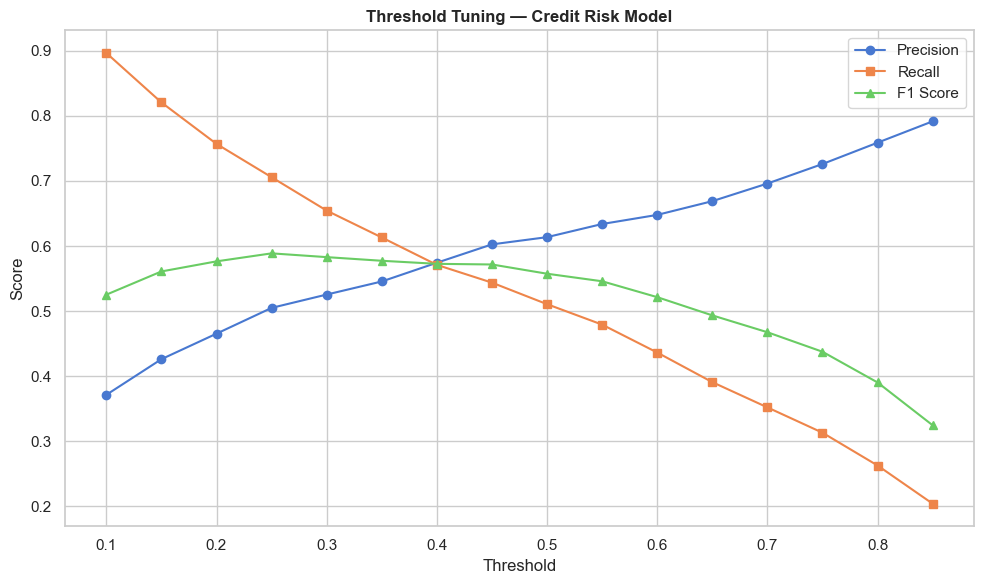

In [67]:
plt.figure(figsize=(10, 6))
plt.plot(thresh_df['Threshold'], thresh_df['Precision'], label='Precision', marker='o')
plt.plot(thresh_df['Threshold'], thresh_df['Recall'],    label='Recall',    marker='s')
plt.plot(thresh_df['Threshold'], thresh_df['F1'],        label='F1 Score',  marker='^')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Tuning — Credit Risk Model', fontweight='bold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [68]:
# Select threshold that maximises F1
optimal_threshold = thresh_df.loc[thresh_df['F1'].idxmax(), 'Threshold']
print(f'Optimal threshold (max F1): {optimal_threshold}')

# Apply optimal threshold to calibrated probabilities
y_pred_final = (calibrated_probs >= optimal_threshold).astype(int)

print(f'\nFinal model performance at threshold = {optimal_threshold}:')
print(classification_report(y_test, y_pred_final, target_names=['No Default', 'Default']))

Optimal threshold (max F1): 0.25

Final model performance at threshold = 0.25:
              precision    recall  f1-score   support

  No Default       0.89      0.78      0.83      3790
     Default       0.51      0.71      0.59      1210

    accuracy                           0.76      5000
   macro avg       0.70      0.74      0.71      5000
weighted avg       0.80      0.76      0.77      5000



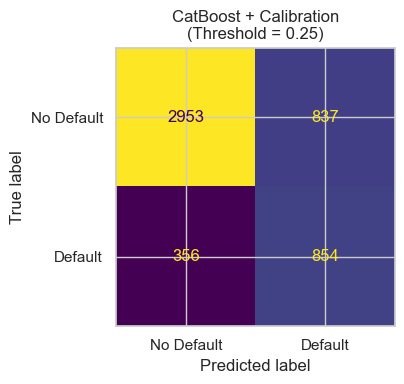

In [69]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=['No Default', 'Default'],
    ax=ax, colorbar=False
)
ax.set_title(f'{best_model_name} + Calibration\n(Threshold = {optimal_threshold})')
plt.tight_layout()
plt.show()

## 11. SHAP Explainability

SHAP (SHapley Additive exPlanations) shows which features drive each prediction and by how much.

In [70]:
# !pip install shap   # uncomment if not installed
import shap

# Use TreeExplainer for tree-based models; fallback to KernelExplainer for MLP/LR
try:
    explainer   = shap.TreeExplainer(best_model_calib)
    shap_values = explainer.shap_values(X_test_scaled)
    # For binary classifiers, shap_values is a list [class0, class1] — take class 1
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values
    expected_value = (
        explainer.expected_value[1]
        if isinstance(explainer.expected_value, (list, np.ndarray))
        else explainer.expected_value
    )
    print('Used TreeExplainer.')
except Exception:
    print('TreeExplainer failed — falling back to KernelExplainer (slower)...')
    background  = shap.sample(X_train_res, 100)
    explainer   = shap.KernelExplainer(best_model_calib.predict_proba, background)
    shap_raw    = explainer.shap_values(X_test_scaled[:200])
    sv          = shap_raw[1] if isinstance(shap_raw, list) else shap_raw
    expected_value = (
        explainer.expected_value[1]
        if isinstance(explainer.expected_value, (list, np.ndarray))
        else explainer.expected_value
    )

feature_names = X_train.columns.tolist()
print(f'SHAP values computed — shape: {sv.shape}')

Used TreeExplainer.
SHAP values computed — shape: (5000, 36)


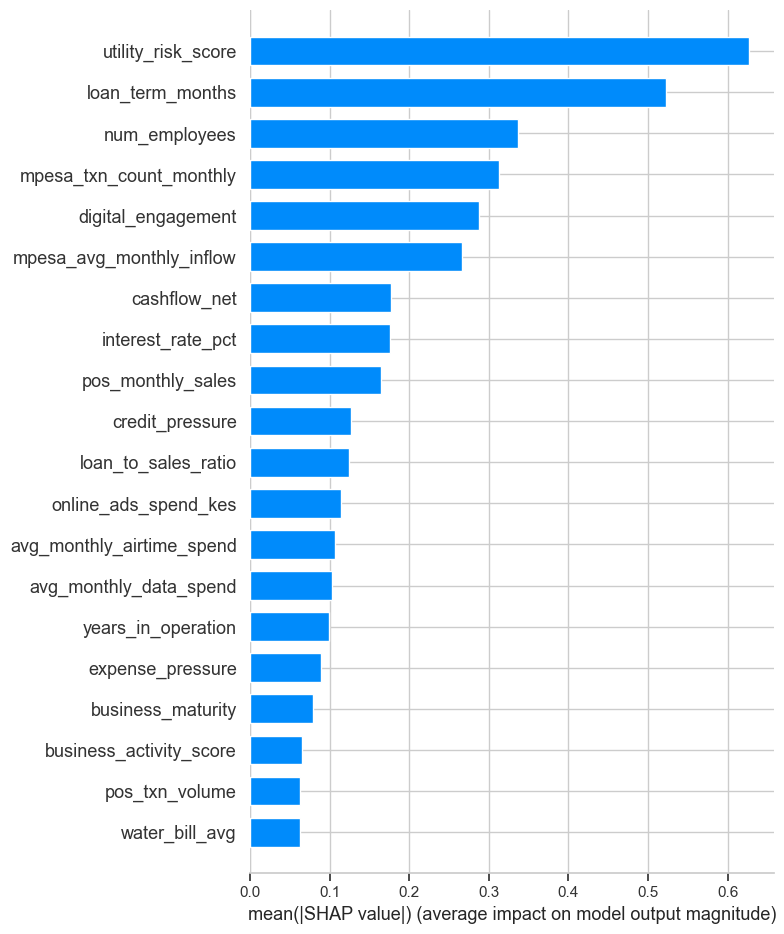

In [71]:
# Global feature importance — mean |SHAP value|
shap.summary_plot(sv, X_test_scaled, feature_names=feature_names, plot_type='bar')

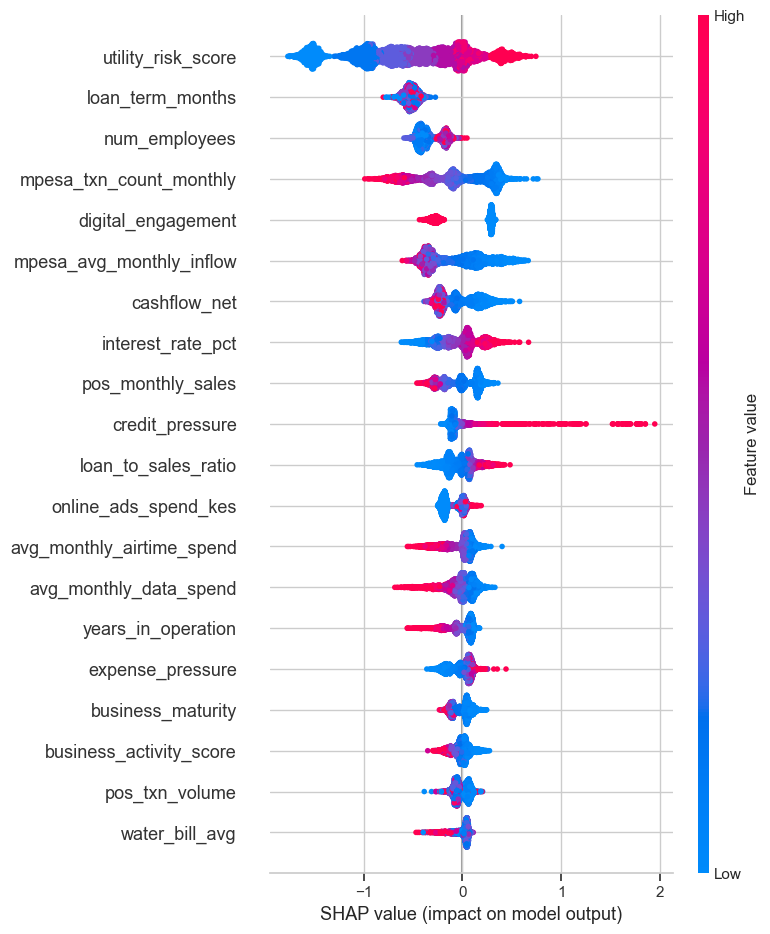

In [72]:
# Beeswarm plot — direction and magnitude of each feature's impact
shap.summary_plot(sv, X_test_scaled, feature_names=feature_names)

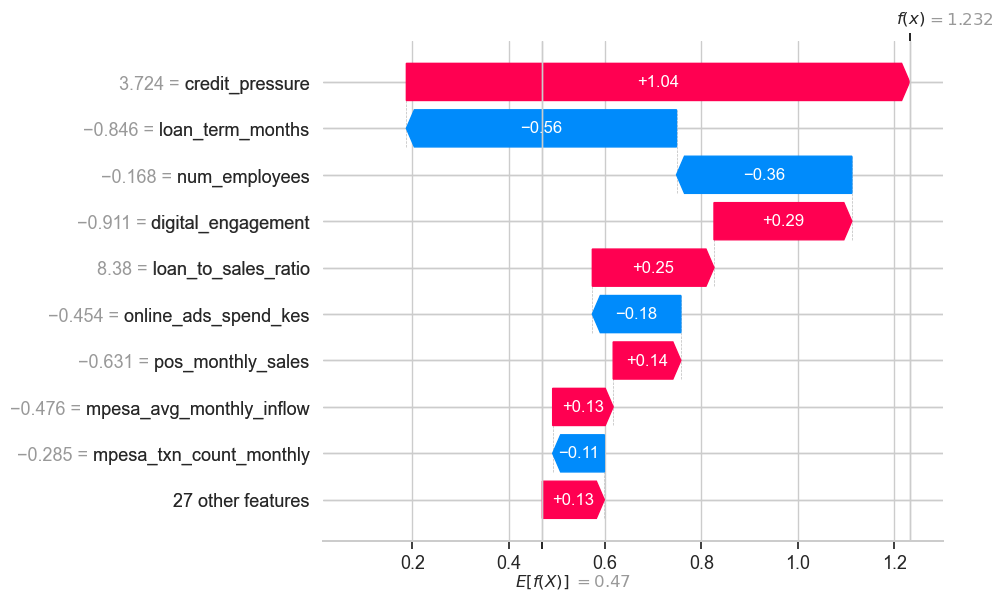

In [73]:
# Waterfall plot for the first test sample (individual explanation)
shap_explanation = shap.Explanation(
    values=sv[0],
    base_values=expected_value,
    data=X_test_scaled[0],
    feature_names=feature_names
)
shap.plots.waterfall(shap_explanation)

In [74]:
# Helper: explain a single SME decision with top risk and protective factors
def explain_decision(i):
    """
    Print the top SHAP-based risk and protective factors for test sample i.

    Parameters
    ----------
    i : int — index of the test sample
    """
    contributions = pd.Series(sv[i], index=feature_names)
    top_risk       = contributions.sort_values(ascending=False).head(3)
    top_protective = contributions.sort_values().head(3)

    print(f'Sample {i} — Calibrated Default Probability: {calibrated_probs[i]:.3f}')
    print(f'Decision: {"REJECT" if y_pred_final[i] == 1 else "APPROVE"}')
    print('\nTop 3 risk factors (push toward default):')
    print(top_risk.round(3).to_string())
    print('\nTop 3 protective factors (push away from default):')
    print(top_protective.round(3).to_string())


explain_decision(0)

Sample 0 — Calibrated Default Probability: 0.883
Decision: REJECT

Top 3 risk factors (push toward default):
credit_pressure        1.045
digital_engagement     0.286
loan_to_sales_ratio    0.253

Top 3 protective factors (push away from default):
loan_term_months       -0.561
num_employees          -0.364
online_ads_spend_kes   -0.184


## 12. Error Analysis

In [75]:
# Build an error analysis dataframe
error_df = X_test.copy()
error_df['actual']      = y_test.values
error_df['predicted']   = y_pred_final
error_df['probability'] = calibrated_probs

false_positives = error_df[(error_df['actual'] == 0) & (error_df['predicted'] == 1)]  # wrongly flagged
false_negatives = error_df[(error_df['actual'] == 1) & (error_df['predicted'] == 0)]  # missed defaults

fp_rate = len(false_positives) / len(error_df)
fn_rate = len(false_negatives) / len(error_df)

print(f'False Positives (wrongly rejected) : {len(false_positives):,}  ({fp_rate:.2%})')
print(f'False Negatives (missed defaults)  : {len(false_negatives):,}  ({fn_rate:.2%})')

False Positives (wrongly rejected) : 837  (16.74%)
False Negatives (missed defaults)  : 356  (7.12%)


In [76]:
key_cols = ['years_in_operation', 'loan_amount_kes', 'mpesa_avg_monthly_inflow', 'utility_risk_score']

print('False Negatives (missed defaults) — key feature summary:')
print(false_negatives[key_cols].describe().round(1))

print('\nFalse Positives (wrongly rejected) — key feature summary:')
print(false_positives[key_cols].describe().round(1))

False Negatives (missed defaults) — key feature summary:
       years_in_operation  loan_amount_kes  mpesa_avg_monthly_inflow  \
count               356.0            356.0                     356.0   
mean                  4.9         672986.9                   77541.4   
std                   5.0        1014016.2                   58188.1   
min                   0.5          24925.0                    8201.0   
25%                   1.4         201763.8                   38783.2   
50%                   3.4         387820.5                   62142.0   
75%                   6.7         706435.8                   96422.0   
max                  35.0        9870888.0                  500595.0   

       utility_risk_score  
count               356.0  
mean                  2.7  
std                   1.7  
min                   0.0  
25%                   1.0  
50%                   2.0  
75%                   4.0  
max                   9.0  

False Positives (wrongly rejected) — key 

## 13. Sector Fairness Analysis

In [77]:
# Attach sector from the original dataframe using the test set index
fairness_df = X_test.copy()
fairness_df['loan_default'] = y_test.values
fairness_df['y_pred']       = y_pred_final
fairness_df['y_prob']       = calibrated_probs
fairness_df['sector']       = df.loc[X_test.index, 'sector'].values

# Default rate (actual) and rejection rate (model) per sector
sector_fairness = fairness_df.groupby('sector').agg(
    default_rate  =('loan_default', 'mean'),
    approval_rate =('y_pred', lambda x: (x == 0).mean())  # predicted 0 = approved
).round(3)

sector_fairness['rejection_rate'] = 1 - sector_fairness['approval_rate']
sector_fairness['bias_gap']       = abs(
    sector_fairness['default_rate'] - sector_fairness['rejection_rate']
).round(3)

print(sector_fairness.sort_values('bias_gap', ascending=False))

               default_rate  approval_rate  rejection_rate  bias_gap
sector                                                              
Informal              0.259          0.577           0.423     0.164
Agribusiness          0.245          0.649           0.351     0.106
Manufacturing         0.230          0.667           0.333     0.103
Wholesale             0.221          0.677           0.323     0.102
Retail                0.238          0.664           0.336     0.098
ICT                   0.277          0.627           0.373     0.096
Transport             0.246          0.667           0.333     0.087
Construction          0.231          0.686           0.314     0.083
Services              0.248          0.677           0.323     0.075
Hospitality           0.244          0.684           0.316     0.072


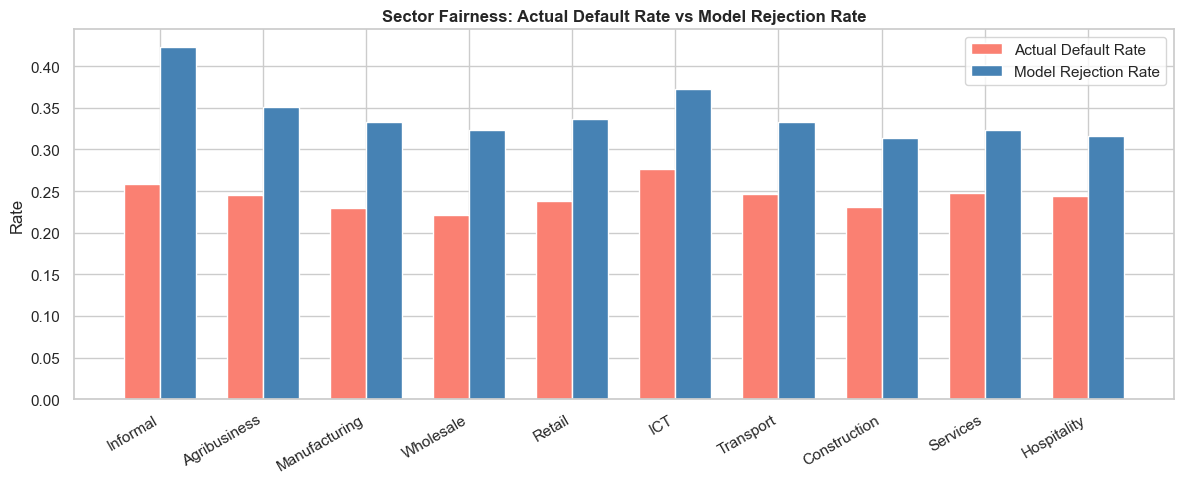

In [78]:
sf = sector_fairness.sort_values('bias_gap', ascending=False)
x  = np.arange(len(sf))
w  = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, sf['default_rate'],   w, label='Actual Default Rate',  color='salmon')
ax.bar(x + w/2, sf['rejection_rate'], w, label='Model Rejection Rate', color='steelblue')
ax.set_xticks(x)
ax.set_xticklabels(sf.index, rotation=30, ha='right')
ax.set_ylabel('Rate')
ax.set_title('Sector Fairness: Actual Default Rate vs Model Rejection Rate', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 14. Credit Scoring System

We convert the calibrated default probability into an interpretable **credit score (300–850)**:

```
credit_score = 850 − (calibrated_probability × 550)
```

Higher default probability → lower credit score.

In [79]:
def compute_credit_score(prob, min_score=300, max_score=850):
    """Convert default probability to a credit score on a 300–850 scale."""
    return max_score - (prob * (max_score - min_score))


def risk_category(score):
    """Assign a risk band based on the credit score."""
    if score >= 750:
        return 'Very Low Risk'
    elif score >= 650:
        return 'Low Risk'
    elif score >= 550:
        return 'Medium Risk'
    elif score >= 450:
        return 'High Risk'
    else:
        return 'Very High Risk'


def lending_decision(score):
    """Map a credit score to a lending action."""
    if score >= 720:
        return 'APPROVE — Premium Loan'
    elif score >= 640:
        return 'APPROVE — Standard Loan'
    elif score >= 560:
        return 'REVIEW — Conditional Approval'
    else:
        return 'REJECT — High Risk'

In [80]:
# Apply the scoring system to the test set
scoring_df = X_test.copy()
scoring_df['actual_default']   = y_test.values
scoring_df['default_prob']     = calibrated_probs
scoring_df['credit_score']     = scoring_df['default_prob'].apply(compute_credit_score).round(1)
scoring_df['risk_category']    = scoring_df['credit_score'].apply(risk_category)
scoring_df['lending_decision'] = scoring_df['credit_score'].apply(lending_decision)

scoring_df[['actual_default','default_prob','credit_score','risk_category','lending_decision']].head(10)

,actual_default,default_prob,credit_score,risk_category,lending_decision
22348,1,0.882617,364.6,Very High Risk,REJECT — High Risk
10905,0,0.564657,539.4,High Risk,REJECT — High Risk
6562,0,0.117048,785.6,Very Low Risk,APPROVE — Premium Loan
5052,0,0.067967,812.6,Very Low Risk,APPROVE — Premium Loan
9069,1,0.815329,401.6,Very High Risk,REJECT — High Risk
24003,0,0.083141,804.3,Very Low Risk,APPROVE — Premium Loan
6996,1,0.405422,627.0,Medium Risk,REVIEW — Conditional Approval
5068,0,0.073549,809.5,Very Low Risk,APPROVE — Premium Loan
11878,0,0.305898,681.8,Low Risk,APPROVE — Standard Loan
13017,0,0.185539,748.0,Low Risk,APPROVE — Premium Loan


Lending Decision Distribution:
lending_decision
APPROVE — Premium Loan           3251
REJECT — High Risk                960
APPROVE — Standard Loan           503
REVIEW — Conditional Approval     286
Name: count, dtype: int64


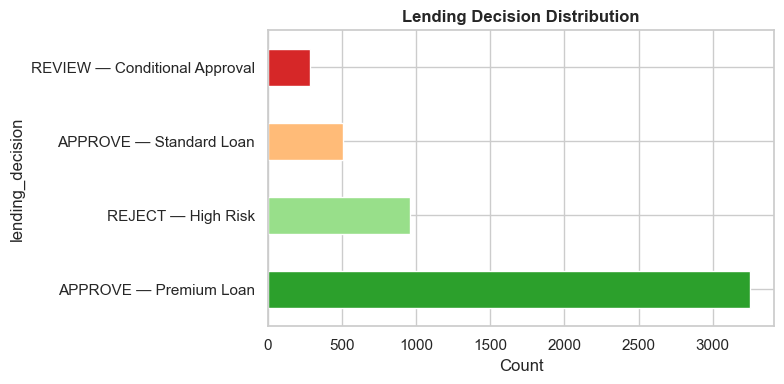

In [81]:
# Lending decision distribution
decision_counts = scoring_df['lending_decision'].value_counts()
print('Lending Decision Distribution:')
print(decision_counts)

plt.figure(figsize=(8, 4))
decision_counts.plot(
    kind='barh',
    color=['#2ca02c', '#98df8a', '#ffbb78', '#d62728']
)
plt.xlabel('Count')
plt.title('Lending Decision Distribution', fontweight='bold')
plt.tight_layout()
plt.show()

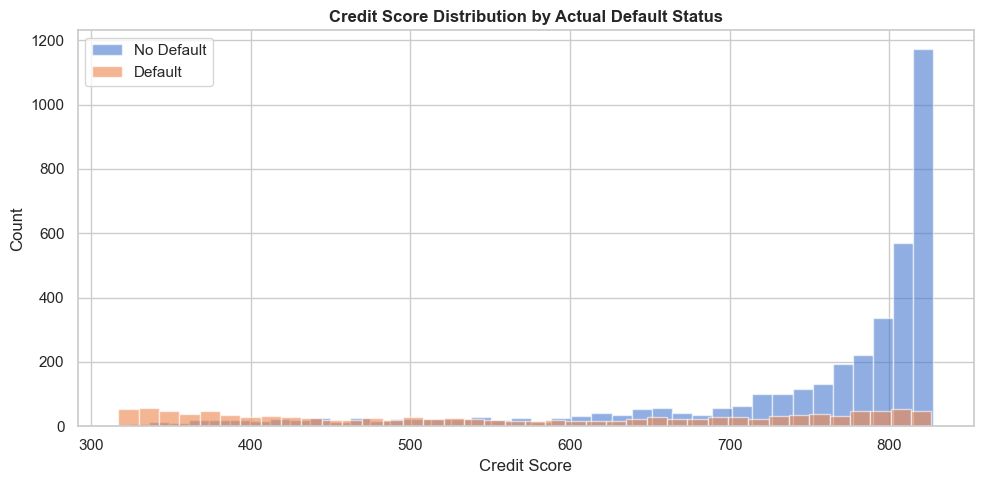

In [82]:
# Credit score distribution by actual default status
plt.figure(figsize=(10, 5))
for label, grp in scoring_df.groupby('actual_default'):
    grp['credit_score'].hist(
        bins=40, alpha=0.6,
        label='No Default' if label == 0 else 'Default'
    )
plt.xlabel('Credit Score')
plt.ylabel('Count')
plt.title('Credit Score Distribution by Actual Default Status', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [83]:
# Risk band validation: actual default rate within each predicted risk band
band_order = ['Very Low Risk', 'Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk']

validation = (
    scoring_df.groupby('risk_category')
    .agg(count=('actual_default', 'count'), actual_default_rate=('actual_default', 'mean'))
    .round(3)
    .reindex([b for b in band_order if b in scoring_df['risk_category'].unique()])
)

print('Risk Band Validation (actual default rate per band):')
print(validation)

Risk Band Validation (actual default rate per band):
                count  actual_default_rate
risk_category                             
Very Low Risk    2916                0.092
Low Risk          773                0.283
Medium Risk       383                0.358
High Risk         357                0.518
Very High Risk    571                0.702


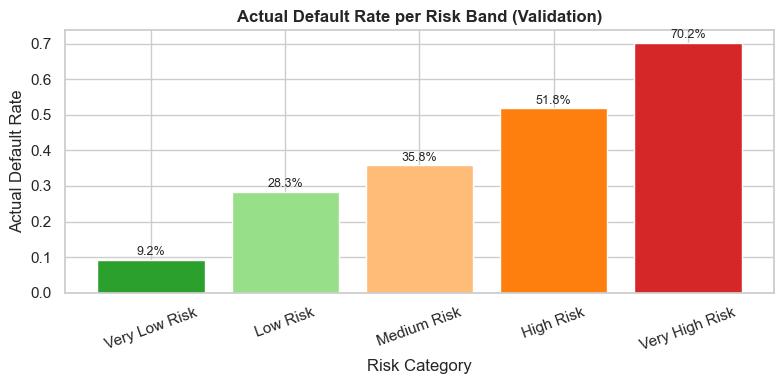

In [84]:
colors = ['#2ca02c', '#98df8a', '#ffbb78', '#ff7f0e', '#d62728']

plt.figure(figsize=(8, 4))
bars = plt.bar(
    validation.index,
    validation['actual_default_rate'],
    color=colors[:len(validation)]
)
for bar, val in zip(bars, validation['actual_default_rate']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{val:.1%}', ha='center', va='bottom', fontsize=9
    )
plt.xlabel('Risk Category')
plt.ylabel('Actual Default Rate')
plt.title('Actual Default Rate per Risk Band (Validation)', fontweight='bold')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 15. Flag Rules Engine

The flag rules engine is a business-logic layer that runs **on top of the model score**. Even if the model gives a borderline score, certain hard red-flags (e.g. extreme leverage, chronic utility defaults) can force a rejection. This catches edge cases the model alone may miss.

In [85]:
def flag_rules(row):
    """
    Apply business-rule flags to a single SME row.

    Returns a list of triggered flag strings.
    Each flag name describes the specific risk detected.
    """
    flags = []

    # Very low credit score — model is highly confident of default
    if row['credit_score'] < 450:
        flags.append('VERY_LOW_SCORE')

    # High utility risk — 6+ electricity payment delays signals financial stress
    if row['utility_risk_score'] >= 6:
        flags.append('HIGH_UTILITY_RISK')

    # Excessive leverage — loan is more than 50x monthly POS sales
    if row['loan_to_sales_ratio'] > 50:
        flags.append('EXCESSIVE_LEVERAGE')

    # Very low M-Pesa activity — fewer than 50 transactions/month
    if row['mpesa_txn_count_monthly'] < 50:
        flags.append('LOW_ACTIVITY')

    # Very high interest rate — borrower is already in a costly loan
    if row['interest_rate_pct'] > 25:
        flags.append('HIGH_INTEREST_RISK')

    return flags


def final_decision(row):
    """
    Combine the model credit score with the flag rules to make
    a final lending decision.

    Hard rejection flags override the model score.
    """
    flags = row['flags']

    # --- Hard rejection rules ---
    if 'VERY_LOW_SCORE' in flags:
        return 'REJECT — Credit Score Too Low'

    if 'EXCESSIVE_LEVERAGE' in flags:
        return 'REJECT — Overleveraged Business'

    if 'HIGH_UTILITY_RISK' in flags:
        return 'REJECT — High Utility Risk'

    # --- Conditional review zone ---
    if row['credit_score'] < 600:
        return 'REVIEW — Manual Assessment Required'

    # --- Approve tiers ---
    if row['credit_score'] < 700:
        return 'APPROVE — Standard Loan'

    return 'APPROVE — Premium Loan'

In [86]:
# Apply flag rules and final decision to the scoring dataframe
# scoring_df already has: credit_score, utility_risk_score, loan_to_sales_ratio,
# mpesa_txn_count_monthly, interest_rate_pct (all from X_test)

scoring_df['flags']          = scoring_df.apply(flag_rules, axis=1)
scoring_df['final_decision'] = scoring_df.apply(final_decision, axis=1)

scoring_df[['credit_score', 'risk_category', 'flags', 'final_decision']].head(10)

,credit_score,risk_category,flags,final_decision
22348,364.6,Very High Risk,"[VERY_LOW_SCORE, EXCESSIVE_LEVERAGE]",REJECT — Credit Score Too Low
10905,539.4,High Risk,[],REVIEW — Manual Assessment Required
6562,785.6,Very Low Risk,[HIGH_UTILITY_RISK],REJECT — High Utility Risk
5052,812.6,Very Low Risk,[],APPROVE — Premium Loan
9069,401.6,Very High Risk,"[VERY_LOW_SCORE, HIGH_UTILITY_RISK]",REJECT — Credit Score Too Low
24003,804.3,Very Low Risk,[],APPROVE — Premium Loan
6996,627.0,Medium Risk,[],APPROVE — Standard Loan
5068,809.5,Very Low Risk,[],APPROVE — Premium Loan
11878,681.8,Low Risk,[],APPROVE — Standard Loan
13017,748.0,Low Risk,[HIGH_UTILITY_RISK],REJECT — High Utility Risk


Final Decision Distribution (model + flag rules):
final_decision
APPROVE — Premium Loan                 3240
REJECT — Credit Score Too Low           571
APPROVE — Standard Loan                 400
REJECT — High Utility Risk              356
REVIEW — Manual Assessment Required     355
REJECT — Overleveraged Business          78
Name: count, dtype: int64


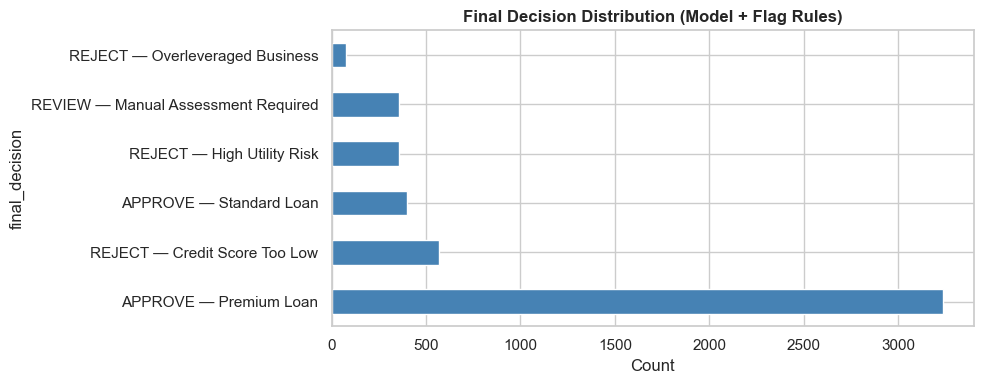

In [87]:
# Distribution of final decisions (model + rules combined)
final_counts = scoring_df['final_decision'].value_counts()
print('Final Decision Distribution (model + flag rules):')
print(final_counts)

plt.figure(figsize=(10, 4))
final_counts.plot(kind='barh', color='steelblue')
plt.xlabel('Count')
plt.title('Final Decision Distribution (Model + Flag Rules)', fontweight='bold')
plt.tight_layout()
plt.show()

In [88]:
# How many applications had at least one flag triggered?
scoring_df['flag_count'] = scoring_df['flags'].apply(len)
flagged = scoring_df[scoring_df['flag_count'] > 0]

print(f'Applications with at least 1 flag: {len(flagged):,} ({len(flagged)/len(scoring_df):.1%})')

# Which flags were triggered most often?
from collections import Counter
all_flags = [flag for flags in scoring_df['flags'] for flag in flags]
flag_counts = pd.Series(Counter(all_flags)).sort_values(ascending=False)

print('\nFlag frequency:')
print(flag_counts)

Applications with at least 1 flag: 1,184 (23.7%)

Flag frequency:
HIGH_UTILITY_RISK     680
VERY_LOW_SCORE        571
HIGH_INTEREST_RISK    290
EXCESSIVE_LEVERAGE    120
LOW_ACTIVITY           79
dtype: int64


In [89]:
# Sector fairness using final_decision
fairness_df['final_decision'] = scoring_df.loc[fairness_df.index, 'final_decision'].values

sector_fairness_final = fairness_df.groupby('sector').agg(
    default_rate     =('loan_default', 'mean'),
    approval_rate_final=('final_decision', lambda x: x.str.contains('APPROVE').mean())
).round(3)

sector_fairness_final['bias_gap'] = abs(
    sector_fairness_final['default_rate'] -
    (1 - sector_fairness_final['approval_rate_final'])
).round(3)

print('Sector Fairness (Final Decision):')
print(sector_fairness_final.sort_values('bias_gap', ascending=False))

Sector Fairness (Final Decision):
               default_rate  approval_rate_final  bias_gap
sector                                                    
Construction          0.231                0.725     0.044
Agribusiness          0.245                0.712     0.043
Retail                0.238                0.723     0.039
Wholesale             0.221                0.743     0.036
Manufacturing         0.230                0.738     0.032
Transport             0.246                0.727     0.027
Informal              0.259                0.720     0.021
ICT                   0.277                0.708     0.015
Services              0.248                0.739     0.013
Hospitality           0.244                0.744     0.012


## 16. End-to-End Single SME Scoring Function

In [90]:
def score_sme(input_dict):
    """
    Score a single SME from raw feature inputs.

    Parameters
    ----------
    input_dict : dict — raw SME features (same columns as training data)

    Returns
    -------
    dict with default_probability, credit_score, risk_category,
         lending_decision, flags, final_decision
    """
    row = pd.DataFrame([input_dict])

    # Feature engineering (mirror training pipeline)
    row['cashflow_net']            = row['mpesa_avg_monthly_inflow'] - row['mpesa_avg_monthly_outflow']
    row['cashflow_ratio']          = row['mpesa_avg_monthly_inflow'] / (row['mpesa_avg_monthly_outflow'] + 1)
    row['loan_to_sales_ratio']     = row['loan_amount_kes'] / (row['pos_monthly_sales'] + 1)
    row['credit_pressure']         = row['loan_amount_kes'] / (row['mpesa_avg_monthly_inflow'] + 1)
    row['business_activity_score'] = row['num_employees'] * row['mpesa_txn_count_monthly']
    row['revenue_per_employee']    = row['pos_monthly_sales'] / (row['num_employees'] + 1)
    row['business_maturity']       = row['years_in_operation'] * row['num_employees']
    row['digital_engagement']      = row['social_media_active'] + (row['online_ads_spend_kes'] > 0).astype(int)
    row['utility_risk_score']      = row['electricity_payment_delays']
    row['high_utility_risk']       = (row['electricity_payment_delays'] > 5).astype(int)
    row['expense_pressure']        = (row['electricity_bill_avg'] + row['water_bill_avg']) / (row['mpesa_avg_monthly_inflow'] + 1)

    # Drop columns not used in modelling
    drop_cols = ['dataset_source', 'electricity_payment_delays', 'social_media_active']
    row.drop(columns=[c for c in drop_cols if c in row.columns], inplace=True)

    # Encode and align
    row = pd.get_dummies(row, columns=['sector'], drop_first=True)
    row = row.reindex(columns=X_train.columns, fill_value=0)

    # Scale
    row_scaled = scaler.transform(row)

    # Raw probability from best model
    raw_prob = best_model_calib.predict_proba(row_scaled)[:, 1][0]

    # Calibrated probability
    cal_prob = calibrator.predict_proba([[raw_prob]])[:, 1][0]

    # Credit score and risk labels
    score    = compute_credit_score(cal_prob)
    risk     = risk_category(score)
    decision = lending_decision(score)

    # Flag rules
    flag_row = {
        'credit_score'           : score,
        'utility_risk_score'     : input_dict.get('electricity_payment_delays', 0),
        'loan_to_sales_ratio'    : input_dict['loan_amount_kes'] / (input_dict['pos_monthly_sales'] + 1),
        'mpesa_txn_count_monthly': input_dict['mpesa_txn_count_monthly'],
        'interest_rate_pct'      : input_dict['interest_rate_pct'],
    }
    flags         = flag_rules(pd.Series(flag_row))
    final         = final_decision(pd.Series({'credit_score': score, 'flags': flags}))

    return {
        'raw_probability'      : round(raw_prob, 4),
        'calibrated_probability': round(cal_prob, 4),
        'credit_score'         : round(score, 1),
        'risk_category'        : risk,
        'lending_decision'     : decision,
        'flags'                : flags,
        'final_decision'       : final,
    }

In [91]:
# Example: score a hypothetical SME
sample_sme = {
    'sector'                   : 'Retail',
    'years_in_operation'       : 5.0,
    'num_employees'            : 8,
    'loan_amount_kes'          : 500_000,
    'loan_term_months'         : 24,
    'interest_rate_pct'        : 18.5,
    'mpesa_avg_monthly_inflow' : 150_000,
    'mpesa_avg_monthly_outflow': 90_000,
    'mpesa_txn_count_monthly'  : 200,
    'mpesa_savings_ratio'      : 0.35,
    'electricity_payment_delays': 1,
    'electricity_bill_avg'     : 5_000,
    'water_bill_avg'           : 2_000,
    'social_media_active'      : 1,
    'online_ads_spend_kes'     : 3_000,
    'avg_monthly_data_spend'   : 1_500,
    'avg_monthly_airtime_spend': 800,
    'pos_monthly_sales'        : 200_000,
    'pos_txn_volume'           : 350,
}

result = score_sme(sample_sme)

print('SME Credit Assessment')
print('=' * 40)
for k, v in result.items():
    print(f'  {k:<25}: {v}')

SME Credit Assessment
  raw_probability          : 0.0887
  calibrated_probability   : 0.0698
  credit_score             : 811.6
  risk_category            : Very Low Risk
  lending_decision         : APPROVE — Premium Loan
  flags                    : []
  final_decision           : APPROVE — Premium Loan


## 17. Save the Model & Artefacts

In [92]:
import joblib

joblib.dump(best_model_calib, 'sme_credit_model.pkl')
joblib.dump(calibrator,       'calibrator.pkl')
joblib.dump(scaler,           'scaler.pkl')

print(f'Model ({best_model_name}) saved as sme_credit_model.pkl')
print('Calibrator saved as calibrator.pkl')
print('Scaler saved as scaler.pkl')

Model (CatBoost) saved as sme_credit_model.pkl
Calibrator saved as calibrator.pkl
Scaler saved as scaler.pkl


In [93]:
# Verify: load and run a quick sanity check
loaded_model      = joblib.load('sme_credit_model.pkl')
loaded_calibrator = joblib.load('calibrator.pkl')
loaded_scaler     = joblib.load('scaler.pkl')

raw    = loaded_model.predict_proba(X_test_scaled[:1])[:, 1]
cal    = loaded_calibrator.predict_proba(raw.reshape(-1, 1))[:, 1]
score  = compute_credit_score(cal[0])

print(f'Sanity check — Sample 0:')
print(f'  Raw probability       : {raw[0]:.4f}')
print(f'  Calibrated probability: {cal[0]:.4f}')
print(f'  Credit score          : {score:.1f}')
print(f'  Risk category         : {risk_category(score)}')
print(f'  Lending decision      : {lending_decision(score)}')

Sanity check — Sample 0:
  Raw probability       : 0.7742
  Calibrated probability: 0.8826
  Credit score          : 364.6
  Risk category         : Very High Risk
  Lending decision      : REJECT — High Risk
